<a href="https://colab.research.google.com/github/bewww831/FINLENS/blob/main/time_series.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Stock Prediction
**Buy / Hold / Sell: XGBoost (tuned) + LSTM + GRU | Medium-term 21-day horizon**


# Install & Imports

In [ ]:
!pip install yfinance xgboost scikit-learn pandas numpy matplotlib seaborn backtesting optuna torch torchvision -q

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

import yfinance as yf
from xgboost import XGBClassifier
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_sample_weight
from backtesting import Backtest, Strategy

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'All imports OK, Device: {DEVICE}')

All imports OK, Device: cpu


#Configuration

In [ ]:
MODEL_NAME = 'xgboost'

TICKERS = [
    'AAPL', 'MSFT', 'GOOGL', 'AMZN', 'META',
    'JPM',  'BAC',  'GS',
    'XOM',  'CVX',
    'JNJ',  'PFE',
    'WMT',  'HD',
    'TSLA', 'NVDA',
]

#Date range
START_DATE = '2010-01-01'
END_DATE   = '2025-12-31'

#Label thresholds
HORIZON        = 21      #days forward to look
BUY_THRESHOLD  =  0.05   #gain > 5%
SELL_THRESHOLD = -0.04   #drop > 4%
MAX_DRAWDOWN   = -0.08   #reject BUY if drops >8% along the way, too much swing

#Cross-validation
TEST_FRACTION = 0.2    #test last 20% of data
N_CV_SPLITS   = 5      #Split folds
CV_GAP        = 21     #gap between train/val to prevent leakage

print(f'Model: {MODEL_NAME} \nTickers: {len(TICKERS)} \nFrom: {START_DATE} to {END_DATE}')

Model: xgboost 
Tickers: 16 
From: 2010-01-01 to 2025-12-31


#Download Price Data

In [ ]:
def download_data(tickers, start, end):
    print(f'Downloading {len(TICKERS)} tickers from: {START_DATE} to {END_DATE}')
    stock_data = {}

    for ticker in tickers:
        try:
            df = yf.download(ticker, start=start, end=end,
                             auto_adjust=True, progress=False)
            if len(df) > 300:
                df.columns = [c[0] if isinstance(c, tuple) else c for c in df.columns]
                stock_data[ticker] = df
                print(f'  (ok) {ticker}: {len(df)} rows')
            else:
                print(f'  (skip) {ticker}: too few rows, skipped')
        except Exception as e:
            print(f'  (fail) {ticker}: {e}')

    print('\nFetching Benchmarks...')
    spy = yf.download('SPY',  start=start, end=end, auto_adjust=True, progress=False)
    vix = yf.download('^VIX', start=start, end=end, auto_adjust=True, progress=False)
    spy.columns = [c[0] if isinstance(c, tuple) else c for c in spy.columns]
    vix.columns = [c[0] if isinstance(c, tuple) else c for c in vix.columns]
    print(f"(done) SPY: {len(spy)} rows, VIX: {len(vix)} rows\n")

    return stock_data, spy, vix

In [ ]:
stock_data, spy, vix = download_data(TICKERS, START_DATE, END_DATE)

  (ok) AAPL: 4023 rows
  (ok) MSFT: 4023 rows
  (ok) GOOGL: 4023 rows
  (ok) AMZN: 4023 rows
  (ok) META: 3424 rows
  (ok) JPM: 4023 rows
  (ok) BAC: 4023 rows
  (ok) GS: 4023 rows
  (ok) XOM: 4023 rows
  (ok) CVX: 4023 rows
  (ok) JNJ: 4023 rows
  (ok) PFE: 4023 rows
  (ok) WMT: 4023 rows
  (ok) HD: 4023 rows
  (ok) TSLA: 3901 rows
  (ok) NVDA: 4023 rows

Fetching Benchmarks...
(done) SPY: 4023 rows, VIX: 4023 rows



# Feature Engineering

In [ ]:
FEATURE_COLS = [
    'ret_1d', 'ret_5d', 'ret_21d', 'ret_63d',
    'vol_10', 'vol_21', 'vol_63', 'vol_ratio',
    'price_vs_sma20', 'price_vs_sma50', 'price_vs_sma200',
    'sma20_vs_sma50', 'sma50_vs_sma200',
    'rsi14', 'rsi14_change',
    'macd_norm', 'macd_hist',
    'bb_pos', 'bb_width',
    'atr14_norm',
    'range_pct', 'gap_pct', 'close_pos',
    'vol_ratio_5d', 'vol_ratio_21d', 'obv_ratio',
    'spy_above_200ma', 'spy_ret_21d',
    'vix_level', 'vix_5d_change', 'vix_vs_sma20',
    'rs_vs_spy_21d', 'rs_vs_spy_5d',
]

def build_features(df, spy, vix):
    df = df.copy()

    # Returns
    df['ret_1d']  = df['Close'].pct_change(1)
    df['ret_5d']  = df['Close'].pct_change(5)
    df['ret_21d'] = df['Close'].pct_change(21)
    df['ret_63d'] = df['Close'].pct_change(63)

    # Volatility
    df['vol_10']    = df['ret_1d'].rolling(10).std()
    df['vol_21']    = df['ret_1d'].rolling(21).std()
    df['vol_63']    = df['ret_1d'].rolling(63).std()
    df['vol_ratio'] = df['vol_10'] / (df['vol_63'] + 1e-9)

    # Moving averages as ratios (scale-invariant)
    sma20  = df['Close'].rolling(20).mean()
    sma50  = df['Close'].rolling(50).mean()
    sma200 = df['Close'].rolling(200).mean()
    df['price_vs_sma20']  = df['Close'] / sma20  - 1
    df['price_vs_sma50']  = df['Close'] / sma50  - 1
    df['price_vs_sma200'] = df['Close'] / sma200 - 1
    df['sma20_vs_sma50']  = sma20 / sma50  - 1
    df['sma50_vs_sma200'] = sma50 / sma200 - 1

    # RSI(14) — Wilder smoothing
    delta    = df['Close'].diff()
    avg_gain = delta.clip(lower=0).ewm(com=13, adjust=False).mean()
    avg_loss = (-delta.clip(upper=0)).ewm(com=13, adjust=False).mean()
    df['rsi14']        = 100 - (100 / (1 + avg_gain / (avg_loss + 1e-9)))
    df['rsi14_change'] = df['rsi14'].diff(5)

    # MACD (12,26,9)
    ema12 = df['Close'].ewm(span=12, adjust=False).mean()
    ema26 = df['Close'].ewm(span=26, adjust=False).mean()
    macd  = ema12 - ema26
    df['macd_norm'] = macd / df['Close']
    df['macd_hist'] = macd - macd.ewm(span=9, adjust=False).mean()

    # Bollinger Bands
    bb_mid   = df['Close'].rolling(20).mean()
    bb_std   = df['Close'].rolling(20).std()
    bb_upper = bb_mid + 2 * bb_std
    bb_lower = bb_mid - 2 * bb_std
    df['bb_pos']   = (df['Close'] - bb_lower) / (bb_upper - bb_lower + 1e-9)
    df['bb_width'] = (bb_upper - bb_lower) / (bb_mid + 1e-9)

    # ATR(14)
    prev_close = df['Close'].shift(1)
    tr = pd.concat([
        df['High'] - df['Low'],
        (df['High'] - prev_close).abs(),
        (df['Low']  - prev_close).abs()
    ], axis=1).max(axis=1)
    df['atr14_norm'] = tr.rolling(14).mean() / df['Close']

    # Price patterns
    df['range_pct'] = (df['High'] - df['Low']) / df['Close']
    df['gap_pct']   = (df['Open'] - prev_close) / (prev_close + 1e-9)
    df['close_pos'] = (df['Close'] - df['Low']) / (df['High'] - df['Low'] + 1e-9)

    # Volume
    if 'Volume' in df.columns:
        vol_ma20 = df['Volume'].rolling(20).mean()
        df['vol_ratio_5d']  = df['Volume'].rolling(5).mean()  / (vol_ma20 + 1)
        df['vol_ratio_21d'] = df['Volume'].rolling(21).mean() / (vol_ma20 + 1)
        obv = (np.sign(df['ret_1d']) * df['Volume']).cumsum()
        df['obv_ratio'] = obv / (obv.rolling(21).mean() + 1e-9)

    # Market regime
    spy_c = spy['Close'].reindex(df.index, method='ffill')
    vix_c = vix['Close'].reindex(df.index, method='ffill')
    df['spy_above_200ma'] = (spy_c > spy_c.rolling(200).mean()).astype(int)
    df['spy_ret_21d']     = spy_c.pct_change(21)
    df['vix_level']       = vix_c
    df['vix_5d_change']   = vix_c.pct_change(5)
    df['vix_vs_sma20']    = vix_c / (vix_c.rolling(20).mean() + 1e-9) - 1

    # Relative strength vs market
    df['rs_vs_spy_21d'] = df['ret_21d'] - df['spy_ret_21d']
    df['rs_vs_spy_5d']  = df['ret_5d']  - spy_c.pct_change(5)

    return df

print(f"build_features defined: {len(FEATURE_COLS)} metrics ready")

build_features defined: 33 metrics ready


# Label Creation


In [ ]:
def create_labels(df, horizon=21, buy_thresh=0.05, sell_thresh=-0.04, max_dd=-0.08):
    df = df.copy()
    close = df['Close'].values
    n = len(close)

    future_returns = np.full(n, np.nan)
    max_drawdowns = np.full(n, np.nan)

    for i in range(n - horizon):
        window = close[i+1 : i+horizon+1]
        future_returns[i] = (window[-1] - close[i]) / close[i]
        max_drawdowns[i] = (window.min() - close[i]) / close[i]

    df['future_return'] = future_returns
    df['max_drawdown_fwd'] = max_drawdowns
    df['label'] = 1   # default HOLD

    buy_mask = (df['future_return'] >  buy_thresh) & (df['max_drawdown_fwd'] > max_dd)
    sell_mask =  df['future_return'] < sell_thresh
    df.loc[buy_mask,  'label'] = 2
    df.loc[sell_mask, 'label'] = 0

    return df

print('Labels created')

Labels created


# Build Combined Dataset


In [ ]:
def build_dataset(stock_data, spy, vix,
                  horizon=HORIZON,
                  buy_thresh=BUY_THRESHOLD,
                  sell_thresh=SELL_THRESHOLD,
                  max_dd=MAX_DRAWDOWN):
    frames = []

    for ticker, raw_df in stock_data.items():
        try:
            df = build_features(raw_df, spy, vix)
            df = create_labels(df, horizon=horizon,
                               buy_thresh=buy_thresh,
                               sell_thresh=sell_thresh,
                               max_dd=max_dd)

            available = [c for c in FEATURE_COLS if c in df.columns]
            df = df.dropna(subset=available + ['label']).copy()
            df['ticker'] = ticker
            frames.append(df[available + ['label', 'ticker']])
        except Exception as e:
            print(f'  Error on {ticker}: {e}')

    combined = pd.concat(frames).sort_index()
    print(f'Combined dataset: {len(combined):,} rows, {combined["ticker"].nunique()} tickers')
    print('\nLabel distribution:')
    dist = combined['label'].value_counts(normalize=True).sort_index()
    dist.index = dist.index.map({0:'SELL', 1:'HOLD', 2:'BUY'})
    print(dist.round(3).to_string())
    return combined

In [ ]:
combined = build_dataset(stock_data, spy, vix)

Combined dataset: 60,463 rows, 16 tickers

Label distribution:
label
SELL    0.199
HOLD    0.507
BUY     0.294


#XGBoost Model

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from xgboost import XGBClassifier

def train_model(combined_df, model_name='model',
                n_splits=5, gap=0,
                test_fraction=0.2):

    available = [c for c in FEATURE_COLS if c in combined_df.columns]
    X = combined_df[available]
    y = combined_df['label']

    tscv = TimeSeriesSplit(n_splits=n_splits, gap=gap)
    fold_results = []
    all_cms = []

    print(f'{model_name} running {n_splits}-fold TimeSeriesSplit CV\n')

    for fold, (train_idx, val_idx) in enumerate(tscv.split(X)):
        X_tr_raw, X_val_raw = X.iloc[train_idx], X.iloc[val_idx]
        y_tr,     y_val     = y.iloc[train_idx], y.iloc[val_idx]

        sc = StandardScaler()
        X_tr  = sc.fit_transform(X_tr_raw)
        X_val = sc.transform(X_val_raw)

        w = compute_sample_weight('balanced', y_tr)

        m = XGBClassifier(
            n_estimators=500, max_depth=4, learning_rate=0.03,
            subsample=0.8, colsample_bytree=0.8,
            min_child_weight=10, gamma=0.1,
            reg_alpha=0.1, reg_lambda=1.0,
            eval_metric='mlogloss',
            early_stopping_rounds=30,
            random_state=42, n_jobs=-1,
        )
        m.fit(X_tr, y_tr, sample_weight=w,
              eval_set=[(X_val, y_val)], verbose=False)

        preds  = m.predict(X_val)

        # Save matrix for this fold
        cm = confusion_matrix(y_val, preds)
        all_cms.append(cm)

        report = classification_report(y_val, preds,
                                       target_names=['SELL','HOLD','BUY'],
                                       output_dict=True,
                                       zero_division=0)

        fold_results.append({
            'fold'          : fold + 1,
            'buy_precision' : report['BUY']['precision'],
            'buy_recall'    : report['BUY']['recall'],
            'sell_precision': report['SELL']['precision'],
            'sell_recall'   : report['SELL']['recall'],
            'accuracy'      : report['accuracy'],
        })

        # FULL PRINT LOGIC RESTORED
        print(f"  (Fold {fold+1}) "
              f"BUY prec: {report['BUY']['precision']:.3f}, rec: {report['BUY']['recall']:.3f} | "
              f"SELL prec: {report['SELL']['precision']:.3f}, rec: {report['SELL']['recall']:.3f} | "
              f"Acc: {report['accuracy']:.3f}")

    #plotting
    print(f"\nPlotting fold results")
    # We add +1 to n_splits to make room for the "Total" matrix at the end
    fig, axes = plt.subplots(1, n_splits + 1, figsize=(4 * (n_splits + 1), 4))

    # Plot individual folds
    for i, cm in enumerate(all_cms):
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['SELL','HOLD','BUY'])
        disp.plot(cmap='Blues', ax=axes[i], colorbar=False)
        axes[i].set_title(f"Fold {i+1}")

    # Plot Total Aggregate Matrix
    total_cm = sum(all_cms)
    disp_total = ConfusionMatrixDisplay(confusion_matrix=total_cm, display_labels=['SELL','HOLD','BUY'])
    disp_total.plot(cmap='Greens', ax=axes[-1], colorbar=False)
    axes[-1].set_title("TOTAL AGGREGATE")

    plt.tight_layout()
    plt.show()


    cv_df = pd.DataFrame(fold_results)
    print(f'\n[{model_name}] CV Averages')
    print(cv_df.mean(numeric_only=True).round(3).to_string())

    print(f'\nTraining final {model_name} on full dataset')
    final_scaler = StandardScaler()
    X_all = final_scaler.fit_transform(X)
    final_w = compute_sample_weight('balanced', y)

    final_model = XGBClassifier(
        n_estimators=500, max_depth=4, learning_rate=0.03,
        subsample=0.8, colsample_bytree=0.8,
        min_child_weight=10, gamma=0.1,
        reg_alpha=0.1, reg_lambda=1.0,
        eval_metric='mlogloss',
        random_state=42, n_jobs=-1,
    )
    final_model.fit(X_all, y, sample_weight=final_w, verbose=False)

    return final_model, final_scaler, available, cv_df

xgboost running 5-fold TimeSeriesSplit CV

  (Fold 1) BUY prec: 0.306, rec: 0.362 | SELL prec: 0.206, rec: 0.252 | Acc: 0.444
  (Fold 2) BUY prec: 0.312, rec: 0.285 | SELL prec: 0.158, rec: 0.198 | Acc: 0.486
  (Fold 3) BUY prec: 0.398, rec: 0.531 | SELL prec: 0.213, rec: 0.187 | Acc: 0.424
  (Fold 4) BUY prec: 0.351, rec: 0.624 | SELL prec: 0.278, rec: 0.196 | Acc: 0.384
  (Fold 5) BUY prec: 0.351, rec: 0.355 | SELL prec: 0.209, rec: 0.270 | Acc: 0.413

Plotting fold results


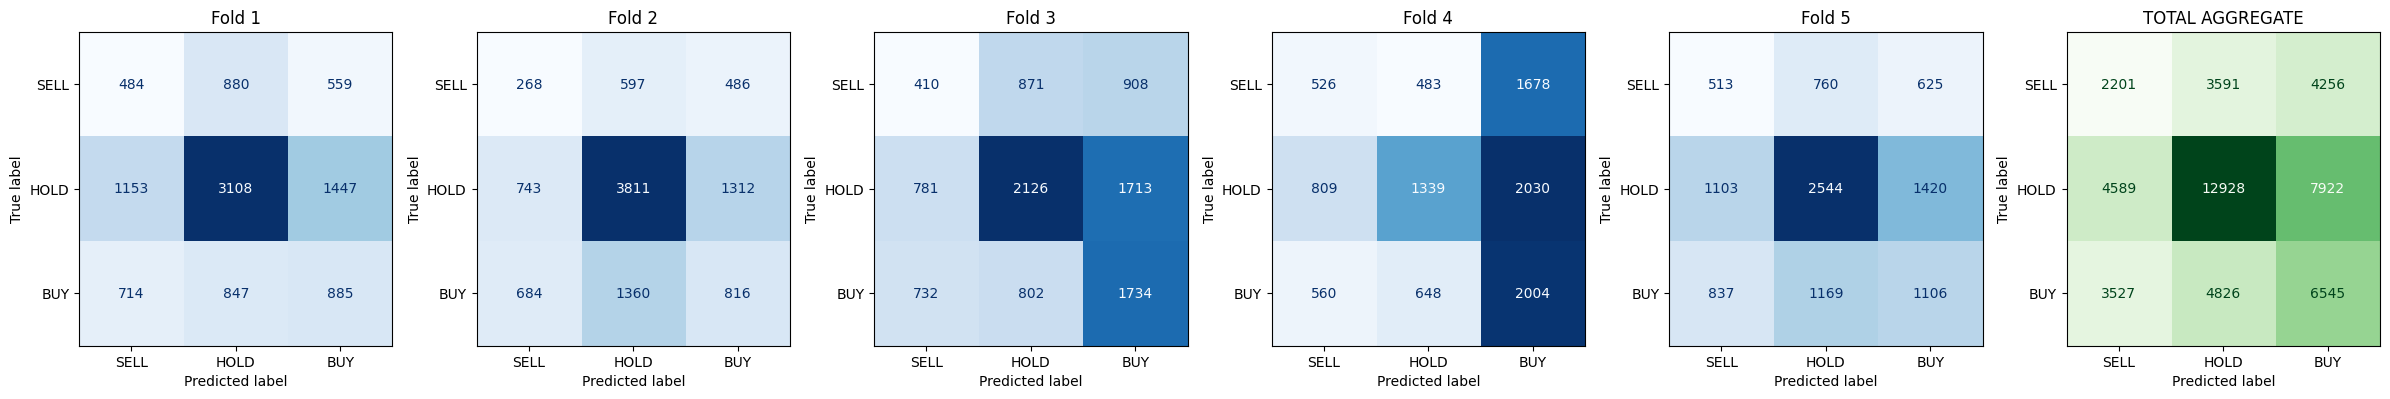


[xgboost] CV Averages
fold              3.000
buy_precision     0.344
buy_recall        0.431
sell_precision    0.213
sell_recall       0.221
accuracy          0.430

Training final xgboost on full dataset


In [ ]:
model, scaler, feature_cols, cv_results = train_model(combined, model_name=MODEL_NAME)

models_registry = getattr(globals(), '__models__', {})
models_registry[MODEL_NAME] = {
    'model'   : model,
    'scaler'  : scaler,
    'features': feature_cols,
    'cv'      : cv_results,
}

In [ ]:
from IPython.display import display, HTML

def evaluate_model(model, scaler, feature_cols, combined_df,
                   model_name='model', test_fraction=0.2):
    available = [c for c in feature_cols if c in combined_df.columns]
    X = combined_df[available]
    y = combined_df['label']

    split     = int(len(X) * (1 - test_fraction))
    X_tr_raw  = X.iloc[:split]
    X_te_raw  = X.iloc[split:]
    y_test    = y.iloc[split:]

    sc = StandardScaler()
    sc.fit(X_tr_raw)
    X_test = sc.transform(X_te_raw)
    preds  = model.predict(X_test)

    print(f'\n[{model_name}] Holdout Evaluation (last {test_fraction*100:.0f}% of combined data)\n')
    print(classification_report(y_test, preds,
                                 target_names=['SELL','HOLD','BUY']))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'[{model_name}] Evaluation', fontsize=13, fontweight='bold')

    # Confusion matrix
    cm = confusion_matrix(y_test, preds)
    ConfusionMatrixDisplay(cm, display_labels=['SELL','HOLD','BUY']).plot(
        ax=axes[0], colorbar=False, cmap='Blues')
    axes[0].set_title('Confusion Matrix')

    # Feature importance
    imp = pd.Series(model.feature_importances_, index=available).nlargest(20)
    imp.sort_values().plot(kind='barh', ax=axes[1], color='steelblue')
    axes[1].set_title('Top 20 Feature Importances')
    axes[1].set_xlabel('Importance Score')

    plt.tight_layout()
    plt.show()

    return preds


[xgboost] Holdout Evaluation (last 20% of combined data)

              precision    recall  f1-score   support

        SELL       0.32      0.58      0.41      2277
        HOLD       0.65      0.50      0.57      5905
         BUY       0.54      0.46      0.49      3911

    accuracy                           0.50     12093
   macro avg       0.50      0.52      0.49     12093
weighted avg       0.55      0.50      0.51     12093



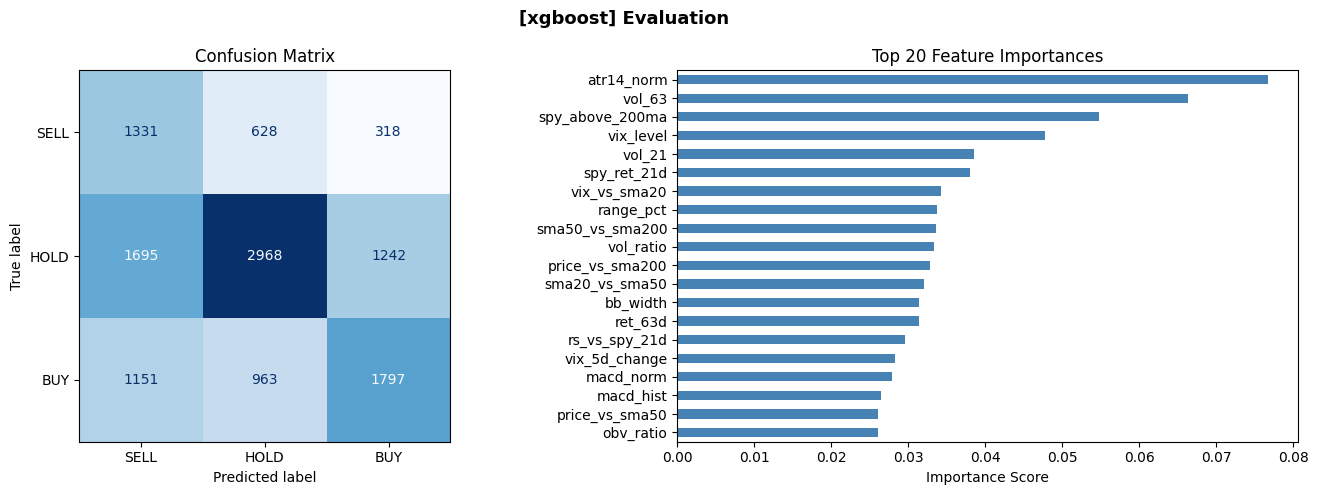

In [ ]:
preds = evaluate_model(model, scaler, feature_cols, combined,
                       model_name=MODEL_NAME,
                       test_fraction=TEST_FRACTION)

#Optuna Hyperparameter Tuning

Optuna intelligently searches hyperparameter combinations (Bayesian optimisation) and finds the best XGBoost config automatically.

In [ ]:
OPTUNA_MODEL_NAME = 'xgboost_tuned'
OPTUNA_N_TRIALS   = 50
OPTUNA_CV_SPLITS  = 3
OPTUNA_CV_GAP     = 21
OPTUNA_METRIC     = 'accuracy'
OPTUNA_FRACTION   = TEST_FRACTION

[xgboost_tuned] Optuna: 50 trials  metric=accuracy  cv=3-fold



  0%|          | 0/50 [00:00<?, ?it/s]


 Best accuracy: 0.4540
  Best params:
    n_estimators           623
    max_depth              8
    learning_rate          0.10855400587457993
    subsample              0.950941928222175
    colsample_bytree       0.42124513973765715
    min_child_weight       3
    gamma                  0.034808116951849245
    reg_alpha              0.7102748086858434
    reg_lambda             3.9668058064705973

Training final [xgboost_tuned] on full train set...
 [xgboost_tuned] done


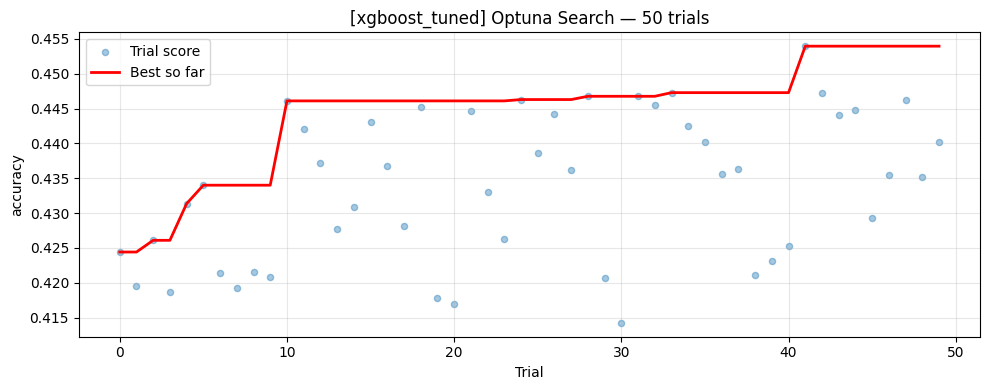

In [ ]:
def tune_xgboost(combined_df, model_name=OPTUNA_MODEL_NAME,
                 n_trials=OPTUNA_N_TRIALS, cv_splits=OPTUNA_CV_SPLITS,
                 cv_gap=OPTUNA_CV_GAP, metric=OPTUNA_METRIC,
                 test_fraction=OPTUNA_FRACTION):

    available = [c for c in FEATURE_COLS if c in combined_df.columns]
    X = combined_df[available]
    y = combined_df['label']

    split  = int(len(X) * (1 - test_fraction))
    X_tune = X.iloc[:split]
    y_tune = y.iloc[:split]
    tscv   = TimeSeriesSplit(n_splits=cv_splits, gap=cv_gap)

    def objective(trial):
        params = {
            'n_estimators'     : trial.suggest_int('n_estimators',      100, 800),
            'max_depth'        : trial.suggest_int('max_depth',            2,   8),
            'learning_rate'    : trial.suggest_float('learning_rate',  0.005, 0.3,  log=True),
            'subsample'        : trial.suggest_float('subsample',        0.5, 1.0),
            'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.4, 1.0),
            'min_child_weight' : trial.suggest_int('min_child_weight',     1,  30),
            'gamma'            : trial.suggest_float('gamma',            0.0, 1.0),
            'reg_alpha'        : trial.suggest_float('reg_alpha',        0.0, 2.0),
            'reg_lambda'       : trial.suggest_float('reg_lambda',       0.5, 5.0),
        }
        fold_scores = []
        for tr_idx, val_idx in tscv.split(X_tune):
            X_tr, X_val = X_tune.iloc[tr_idx], X_tune.iloc[val_idx]
            y_tr, y_val = y_tune.iloc[tr_idx], y_tune.iloc[val_idx]
            sc = StandardScaler()
            X_tr_s  = sc.fit_transform(X_tr)
            X_val_s = sc.transform(X_val)
            w = compute_sample_weight('balanced', y_tr)
            m = XGBClassifier(**params, eval_metric='mlogloss', random_state=42, n_jobs=-1)
            m.fit(X_tr_s, y_tr, sample_weight=w, verbose=False)
            preds  = m.predict(X_val_s)
            report = classification_report(y_val, preds,
                                           target_names=['SELL','HOLD','BUY'],
                                           output_dict=True, zero_division=0)
            if metric == 'buy_f1':          fold_scores.append(report['BUY']['f1-score'])
            elif metric == 'buy_precision': fold_scores.append(report['BUY']['precision'])
            else:                           fold_scores.append(report['accuracy'])
        return np.mean(fold_scores)

    print(f'[{model_name}] Optuna: {n_trials} trials  metric={metric}  cv={cv_splits}-fold\n')
    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)

    best = study.best_params
    print(f'\n Best {metric}: {study.best_value:.4f}')
    print('  Best params:')
    for k, v in best.items():
        print(f'    {k:<22} {v}')

    # Train final model on ALL training data with best params
    print(f'\nTraining final [{model_name}] on full train set...')
    final_sc  = StandardScaler()
    X_all_s   = final_sc.fit_transform(X)
    w_all     = compute_sample_weight('balanced', y)
    best_model = XGBClassifier(**best, eval_metric='mlogloss', random_state=42, n_jobs=-1)
    best_model.fit(X_all_s, y, sample_weight=w_all, verbose=False)
    print(f' [{model_name}] done')

    # Plot search history
    vals       = [t.value for t in study.trials]
    best_curve = [max(vals[:i+1]) for i in range(len(vals))]
    plt.figure(figsize=(10, 4))
    plt.scatter(range(len(vals)), vals, alpha=0.4, s=20, label='Trial score')
    plt.plot(range(len(vals)), best_curve, color='red', linewidth=2, label='Best so far')
    plt.xlabel('Trial')
    plt.ylabel(metric)
    plt.title(f'[{model_name}] Optuna Search — {n_trials} trials')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return best_model, final_sc, available, study


tuned_model, tuned_scaler, tuned_features, optuna_study = tune_xgboost(combined)

#Threshold Tuning
By default the model signals BUY/SELL whenever that class has the highest probability.  
Threshold tuning adds a **minimum confidence requirement** before firing a signal.

In [ ]:
THRESH_MODEL_NAME = OPTUNA_MODEL_NAME
THRESH_FRACTION   = TEST_FRACTION
THRESH_MIN        = 0.30
THRESH_MAX        = 0.70
THRESH_STEPS      = 20

[xgboost_tuned] Threshold Search
 threshold  buy_precision  buy_recall  buy_f1  sell_f1  accuracy  n_buy  n_sell
     0.300         0.9707      0.9184  0.9438   0.9522    0.9494   1947    1127
     0.321         0.9707      0.9184  0.9438   0.9522    0.9494   1947    1127
     0.342         0.9707      0.9184  0.9438   0.9522    0.9494   1947    1127
     0.363         0.9716      0.9155  0.9427   0.9529    0.9486   1939    1121
     0.384         0.9740      0.9111  0.9415   0.9532    0.9467   1925    1112
     0.405         0.9770      0.9062  0.9403   0.9521    0.9451   1909    1104
     0.426         0.9804      0.9004  0.9387   0.9492    0.9429   1890    1094
     0.447         0.9817      0.8887  0.9329   0.9452    0.9375   1863    1078
     0.468         0.9841      0.8698  0.9234   0.9445    0.9312   1819    1054
     0.489         0.9865      0.8503  0.9134   0.9421    0.9246   1774    1030
     0.511         0.9884      0.8304  0.9026   0.9375    0.9171   1729    1002
     0.

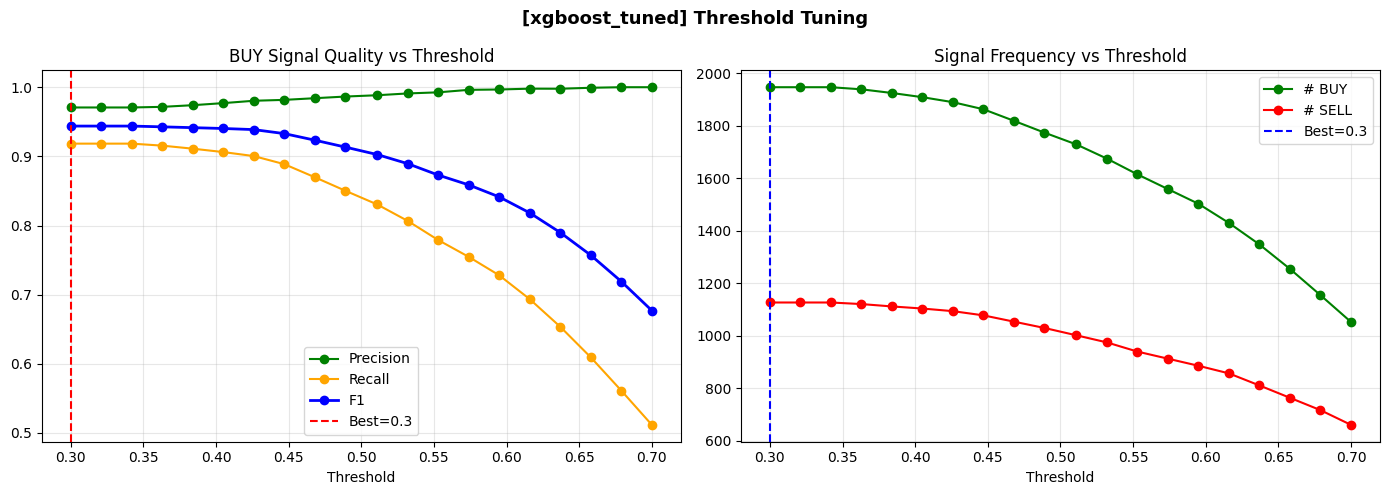

In [ ]:
def tune_threshold(model, scaler, feature_cols, combined_df,
                   model_name='model', test_fraction=0.2,
                   thresh_min=0.30, thresh_max=0.70, steps=20):

    available = [c for c in feature_cols if c in combined_df.columns]
    X = combined_df[available]
    y = combined_df['label']

    # 80% train | 80-90% = tune | 90-100% = untouched holdout
    train_end = int(len(X) * 0.80)
    val_end   = int(len(X) * 0.90)
    sc = StandardScaler()
    sc.fit(X.iloc[:train_end])
    X_val_s = sc.transform(X.iloc[train_end:val_end])
    y_val   = y.iloc[train_end:val_end]
    proba   = model.predict_proba(X_val_s)

    records = []
    for t in np.linspace(thresh_min, thresh_max, steps):
        preds = [int(np.argmax(p)) if p.max() >= t else 1 for p in proba]
        preds = np.array(preds)
        rep   = classification_report(y_val, preds,
                                       target_names=['SELL','HOLD','BUY'],
                                       output_dict=True, zero_division=0)
        records.append({
            'threshold'     : round(t, 3),
            'buy_precision' : round(rep['BUY']['precision'], 4),
            'buy_recall'    : round(rep['BUY']['recall'],    4),
            'buy_f1'        : round(rep['BUY']['f1-score'],  4),
            'sell_f1'       : round(rep['SELL']['f1-score'], 4),
            'accuracy'      : round(rep['accuracy'],         4),
            'n_buy'         : int((preds == 2).sum()),
            'n_sell'        : int((preds == 0).sum()),
        })

    results_df  = pd.DataFrame(records)
    best_idx    = results_df['buy_f1'].idxmax()
    best_thresh = results_df.loc[best_idx, 'threshold']

    print(f'[{model_name}] Threshold Search')
    print(results_df.to_string(index=False))
    print(f'\n  Best threshold : {best_thresh}')
    print(f'     BUY F1        : {results_df.loc[best_idx, "buy_f1"]:.4f}')
    print(f'     BUY Precision : {results_df.loc[best_idx, "buy_precision"]:.4f}')
    print(f'     BUY signals   : {results_df.loc[best_idx, "n_buy"]}')

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'[{model_name}] Threshold Tuning', fontsize=13, fontweight='bold')
    axes[0].plot(results_df['threshold'], results_df['buy_precision'], marker='o', label='Precision', color='green')
    axes[0].plot(results_df['threshold'], results_df['buy_recall'],    marker='o', label='Recall',    color='orange')
    axes[0].plot(results_df['threshold'], results_df['buy_f1'],        marker='o', label='F1',        color='blue', linewidth=2)
    axes[0].axvline(best_thresh, color='red', linestyle='--', linewidth=1.5, label=f'Best={best_thresh}')
    axes[0].set_xlabel('Threshold')
    axes[0].set_title('BUY Signal Quality vs Threshold')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    axes[1].plot(results_df['threshold'], results_df['n_buy'],  marker='o', color='green', label='# BUY')
    axes[1].plot(results_df['threshold'], results_df['n_sell'], marker='o', color='red',   label='# SELL')
    axes[1].axvline(best_thresh, color='blue', linestyle='--', linewidth=1.5, label=f'Best={best_thresh}')
    axes[1].set_xlabel('Threshold')
    axes[1].set_title('Signal Frequency vs Threshold')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return best_thresh, results_df


best_threshold, threshold_results = tune_threshold(
    tuned_model, tuned_scaler, tuned_features, combined,
    model_name    = THRESH_MODEL_NAME,
    test_fraction = THRESH_FRACTION,
    thresh_min    = THRESH_MIN,
    thresh_max    = THRESH_MAX,
    steps         = THRESH_STEPS,
)

In [ ]:
def predict_with_threshold(proba_array, threshold):
    return np.array([int(np.argmax(p)) if p.max() >= threshold else 1
                     for p in proba_array])


# Demo: tuned model + best threshold on holdout
available = [c for c in tuned_features if c in combined.columns]
X_all     = combined[available]
split     = int(len(X_all) * (1 - TEST_FRACTION))
sc_demo   = StandardScaler()
sc_demo.fit(X_all.iloc[:split])
X_test_s  = sc_demo.transform(X_all.iloc[split:])
y_test    = combined['label'].iloc[split:]

proba_test   = tuned_model.predict_proba(X_test_s)
preds_thresh = predict_with_threshold(proba_test, best_threshold)

print(f'[{THRESH_MODEL_NAME}] Holdout results with threshold = {best_threshold}')
print(classification_report(y_test, preds_thresh,
                             target_names=['SELL','HOLD','BUY'], zero_division=0))
print(f'Signals BUY: {(preds_thresh==2).sum()}  '
      f'SELL: {(preds_thresh==0).sum()}  '
      f'HOLD: {(preds_thresh==1).sum()}')

[xgboost_tuned] Holdout results with threshold = 0.3
              precision    recall  f1-score   support

        SELL       0.94      0.97      0.95      2277
        HOLD       0.95      0.97      0.96      5905
         BUY       0.97      0.93      0.95      3911

    accuracy                           0.95     12093
   macro avg       0.95      0.95      0.95     12093
weighted avg       0.95      0.95      0.95     12093

Signals BUY: 3741  SELL: 2339  HOLD: 6013


Baseline XGBoost 

[xgboost] Holdout Evaluation (last 20% of combined data)

              precision    recall  f1-score   support

        SELL       0.32      0.58      0.41      2277
        HOLD       0.65      0.50      0.57      5905
         BUY       0.54      0.46      0.49      3911

    accuracy                           0.50     12093
   macro avg       0.50      0.52      0.49     12093
weighted avg       0.55      0.50      0.51     12093



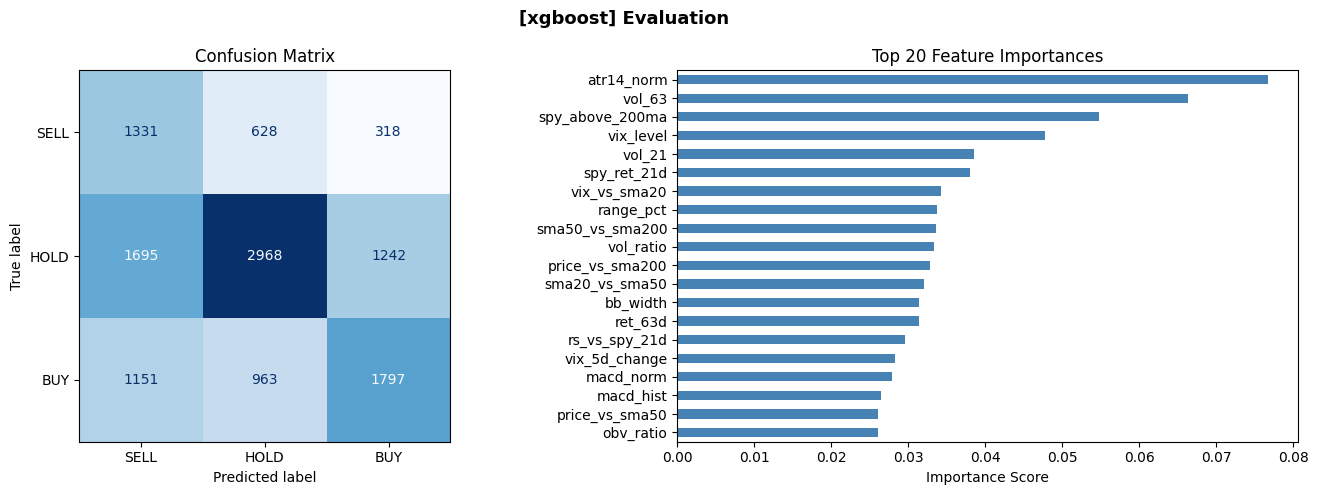


Tuned XGBoost

[xgboost_tuned] Holdout Evaluation (last 20% of combined data)

              precision    recall  f1-score   support

        SELL       0.94      0.97      0.95      2277
        HOLD       0.95      0.97      0.96      5905
         BUY       0.97      0.93      0.95      3911

    accuracy                           0.95     12093
   macro avg       0.95      0.95      0.95     12093
weighted avg       0.95      0.95      0.95     12093



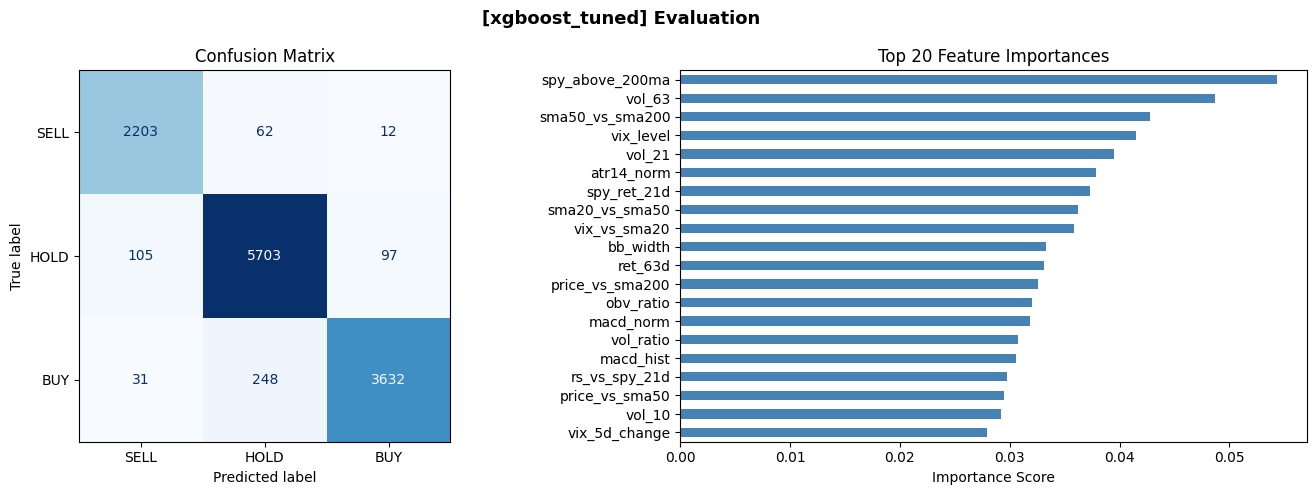

In [ ]:
print('Baseline XGBoost ')
_ = evaluate_model(model, scaler, feature_cols, combined,
                   model_name=MODEL_NAME, test_fraction=TEST_FRACTION)
print('\nTuned XGBoost')
_ = evaluate_model(tuned_model, tuned_scaler, tuned_features, combined,
                   model_name=OPTUNA_MODEL_NAME, test_fraction=TEST_FRACTION)

#Backtesting

In [ ]:
BT_MODEL_NAME  = OPTUNA_MODEL_NAME
BT_TICKER      = 'AMZN'
BT_START       = None
BT_END         = None
BT_CASH        = 10_000
BT_COMMISSION  = 0.003    # 0.3% per trade
BT_FRACTION    = TEST_FRACTION  # must match what was used in training

In [ ]:
def run_backtest(model, scaler, feature_cols, combined_df, stock_data,
                 ticker=BT_TICKER, test_fraction=BT_FRACTION,
                 bt_start=BT_START, bt_end=BT_END,
                 cash=BT_CASH, commission=BT_COMMISSION,
                 model_name=BT_MODEL_NAME):

    df_t = combined_df[combined_df['ticker'] == ticker].copy()
    if len(df_t) == 0:
        print(f"'{ticker}' not found. Available: {list(combined_df['ticker'].unique())}")
        return None, None

    available = [c for c in feature_cols if c in df_t.columns]
    X = df_t[available]
    split = int(len(X) * (1 - test_fraction))

    sc = StandardScaler()
    sc.fit(X.iloc[:split])
    X_test_scaled = sc.transform(X.iloc[split:])
    signals = model.predict(X_test_scaled)

    # Build OHLCV from raw stock_data (combined dropped these columns)
    raw = stock_data[ticker].copy()
    raw.columns = [c[0] if isinstance(c, tuple) else c for c in raw.columns]
    bt_df = raw.loc[X.iloc[split:].index,
                    ['Open','High','Low','Close','Volume']].copy()
    bt_df.index     = pd.to_datetime(bt_df.index)
    bt_df['signal'] = signals

    if bt_start:
        bt_df = bt_df[bt_df.index >= pd.to_datetime(bt_start)]
    if bt_end:
        bt_df = bt_df[bt_df.index <= pd.to_datetime(bt_end)]
    if len(bt_df) < 30:
        print(f'Too few rows after date filter ({len(bt_df)}). Widen the range.')
        return None, None

    class MLStrategy(Strategy):
        def init(self):
            self.ml_signal = self.I(
                lambda: self.data.df['signal'].values,
                name='ML Signal'
            )
        def next(self):
            sig = self.ml_signal[-1]
            if   sig == 2 and not self.position: self.buy()
            elif sig == 0 and     self.position: self.position.close()

    bt    = Backtest(bt_df, MLStrategy, cash=cash,
                     commission=commission, exclusive_orders=True)
    stats = bt.run()

    date_range = f"from {str(stats['Start'])[:10]} to {str(stats['End'])[:10]}"
    print(f"\n{'='*60}")
    print(f"  BACKTESTING — {ticker} {date_range}")
    print(f"{'='*60}")
    rows = [
        ('Starting cash',     f"${cash:,.0f}"),
        ('Final equity',      f"${stats['Equity Final [$]']:,.2f}"),
        ('Strategy return',   f"{stats['Return [%]']:.2f}%"),
        ('Buy & Hold return', f"{stats['Buy & Hold Return [%]']:.2f}%"),
        ('Max drawdown',      f"{stats['Max. Drawdown [%]']:.2f}%"),
        ('Sharpe ratio',      f"{stats['Sharpe Ratio']:.3f}"),
        ('Win rate',          f"{stats['Win Rate [%]']:.1f}%"),
        ('No. of Trades',          stats['# Trades']),
        ('Avg trade return',  f"{stats['Avg. Trade [%]']:.2f}%"),
        ('Profit factor',     f"{stats['Profit Factor']:.2f}" if stats['Profit Factor'] else 'N/A'),
        ('Calmar ratio',      f"{stats['Calmar Ratio']:.3f}"),
    ]
    for name, val in rows:
        print(f'  {name:<24} {val}')
    print(f"\n  Beat Buy&Hold: {'Yes' if stats['Return [%]'] > stats['Buy & Hold Return [%]'] else 'No'}")
    print(f"  Sharpe > 1.0:  {'Yes' if stats['Sharpe Ratio'] > 1 else 'No'}")

    return stats, bt


stats, bt = run_backtest(tuned_model, tuned_scaler, tuned_features, combined, stock_data)

Backtest.run:   0%|          | 0/764 [00:00<?, ?bar/s]


  BACKTESTING — AMZN from 2022-12-12 to 2025-12-30
  Starting cash            $10,000
  Final equity             $56,469.05
  Strategy return          464.69%
  Buy & Hold return        156.80%
  Max drawdown             -12.43%
  Sharpe ratio             1.646
  Win rate                 100.0%
  No. of Trades            15
  Avg trade return         11.80%
  Profit factor            nan
  Calmar ratio             6.186

  Beat Buy&Hold: Yes
  Sharpe > 1.0:  Yes


In [ ]:
all_stats = {}
total_invested = 0

for ticker in stock_data.keys():
    stats, bt = run_backtest(
        tuned_model, tuned_scaler, tuned_features, combined, stock_data,
        ticker=ticker
    )
    if stats is not None:
        all_stats[ticker] = stats
        total_invested += BT_CASH

# Summary
total_final   = sum(s['Equity Final [$]'] for s in all_stats.values())
total_profit  = total_final - total_invested
total_return  = (total_profit / total_invested) * 100 if total_invested > 0 else 0

summary_text = (
    f"\n{'='*40}\n"
    f" XGBOOST TUNED OVERALL PORTFOLIO SUMMARY\n"
    f"{'='*40}\n"
    f"  Tickers traded       {len(all_stats)}\n"
    f"  Total invested       ${total_invested:,.0f}\n"
    f"  Total final equity   ${total_final:,.2f}\n"
    f"  Total profit/loss    ${total_profit:,.2f}\n"
    f"  Overall return       {total_return:.2f}%\n"
)

tuned_xgboost = {
    "tickers_traded": len(all_stats),
    "total_invested": total_invested,
    "total_final_equity": total_final,
    "total_profit_loss": total_profit,
    "overall_return_percent": total_return,
    "per_ticker_stats": all_stats,
    "summary": summary_text
}

print(tuned_xgboost["summary"])

Backtest.run:   0%|          | 0/764 [00:00<?, ?bar/s]


  BACKTESTING — AAPL from 2022-12-12 to 2025-12-30
  Starting cash            $10,000
  Final equity             $19,777.38
  Strategy return          97.77%
  Buy & Hold return        91.85%
  Max drawdown             -14.39%
  Sharpe ratio             1.040
  Win rate                 86.7%
  No. of Trades            15
  Avg trade return         4.09%
  Profit factor            7.39
  Calmar ratio             1.751

  Beat Buy&Hold: Yes
  Sharpe > 1.0:  Yes


Backtest.run:   0%|          | 0/764 [00:00<?, ?bar/s]


  BACKTESTING — MSFT from 2022-12-12 to 2025-12-30
  Starting cash            $10,000
  Final equity             $19,091.54
  Strategy return          90.92%
  Buy & Hold return        97.67%
  Max drawdown             -15.24%
  Sharpe ratio             1.056
  Win rate                 69.2%
  No. of Trades            13
  Avg trade return         5.14%
  Profit factor            5.63
  Calmar ratio             1.557

  Beat Buy&Hold: No
  Sharpe > 1.0:  Yes


Backtest.run:   0%|          | 0/764 [00:00<?, ?bar/s]

...


  BACKTESTING — HD from 2022-12-12 to 2025-12-30
  Starting cash            $10,000
  Final equity             $12,854.31
  Strategy return          28.54%
  Buy & Hold return        13.97%
  Max drawdown             -17.94%
  Sharpe ratio             0.653
  Win rate                 68.4%
  No. of Trades            19
  Avg trade return         1.37%
  Profit factor            2.54
  Calmar ratio             0.481

  Beat Buy&Hold: Yes
  Sharpe > 1.0:  No


Backtest.run:   0%|          | 0/740 [00:00<?, ?bar/s]


  BACKTESTING — TSLA from 2023-01-18 to 2025-12-30
  Starting cash            $10,000
  Final equity             $25,067.11
  Strategy return          150.67%
  Buy & Hold return        252.87%
  Max drawdown             -44.26%
  Sharpe ratio             0.540
  Win rate                 46.7%
  No. of Trades            30
  Avg trade return         3.12%
  Profit factor            2.06
  Calmar ratio             0.829

  Beat Buy&Hold: No
  Sharpe > 1.0:  No


Backtest.run:   0%|          | 0/764 [00:00<?, ?bar/s]


  BACKTESTING — NVDA from 2022-12-12 to 2025-12-30
  Starting cash            $10,000
  Final equity             $43,676.05
  Strategy return          336.76%
  Buy & Hold return        970.59%
  Max drawdown             -27.41%
  Sharpe ratio             0.979
  Win rate                 70.7%
  No. of Trades            41
  Avg trade return         3.50%
  Profit factor            3.83
  Calmar ratio             2.281

  Beat Buy&Hold: No
  Sharpe > 1.0:  No

 XGBOOST TUNED OVERALL PORTFOLIO SUMMARY
  Tickers traded       16
  Total invested       $160,000
  Total final equity   $385,866.75
  Total profit/loss    $225,866.75
  Overall return       141.17%



In [ ]:
all_stats = {}
total_invested = 0

for ticker in stock_data.keys():
    stats, bt = run_backtest(
        model, scaler, feature_cols, combined, stock_data,
        ticker=ticker
    )
    if stats is not None:
        all_stats[ticker] = stats
        total_invested += BT_CASH

# Summary
total_final   = sum(s['Equity Final [$]'] for s in all_stats.values())
total_profit  = total_final - total_invested
total_return  = (total_profit / total_invested) * 100 if total_invested > 0 else 0

# Build formatted summary
summary_text = (
    f"\n{'='*40}\n"
    f"XGBoost  OVERALL PORTFOLIO SUMMARY\n"
    f"{'='*40}\n"
    f"  Tickers traded       {len(all_stats)}\n"
    f"  Total invested       ${total_invested:,.0f}\n"
    f"  Total final equity   ${total_final:,.2f}\n"
    f"  Total profit/loss    ${total_profit:,.2f}\n"
    f"  Overall return       {total_return:.2f}%\n"
)

result_xgboost = {
    "tickers_traded": len(all_stats),
    "total_invested": total_invested,
    "total_final_equity": total_final,
    "total_profit_loss": total_profit,
    "overall_return_percent": total_return,
    "per_ticker_stats": all_stats,
    "summary": summary_text
}

print(result_xgboost["summary"])

Backtest.run:   0%|          | 0/764 [00:00<?, ?bar/s]


  BACKTESTING — AAPL from 2022-12-12 to 2025-12-30
  Starting cash            $10,000
  Final equity             $11,950.14
  Strategy return          19.50%
  Buy & Hold return        91.85%
  Max drawdown             -17.62%
  Sharpe ratio             0.314
  Win rate                 56.2%
  No. of Trades            16
  Avg trade return         1.12%
  Profit factor            1.99
  Calmar ratio             0.343

  Beat Buy&Hold: No
  Sharpe > 1.0:  No


Backtest.run:   0%|          | 0/764 [00:00<?, ?bar/s]


  BACKTESTING — MSFT from 2022-12-12 to 2025-12-30
  Starting cash            $10,000
  Final equity             $13,326.17
  Strategy return          33.26%
  Buy & Hold return        97.67%
  Max drawdown             -23.16%
  Sharpe ratio             0.615
  Win rate                 40.0%
  No. of Trades            15
  Avg trade return         1.99%
  Profit factor            3.00
  Calmar ratio             0.428

  Beat Buy&Hold: No
  Sharpe > 1.0:  No


Backtest.run:   0%|          | 0/764 [00:00<?, ?bar/s]

...


  BACKTESTING — HD from 2022-12-12 to 2025-12-30
  Starting cash            $10,000
  Final equity             $10,837.13
  Strategy return          8.37%
  Buy & Hold return        13.97%
  Max drawdown             -15.08%
  Sharpe ratio             0.243
  Win rate                 44.0%
  No. of Trades            25
  Avg trade return         0.33%
  Profit factor            1.40
  Calmar ratio             0.178

  Beat Buy&Hold: No
  Sharpe > 1.0:  No


Backtest.run:   0%|          | 0/740 [00:00<?, ?bar/s]


  BACKTESTING — TSLA from 2023-01-18 to 2025-12-30
  Starting cash            $10,000
  Final equity             $7,591.15
  Strategy return          -24.09%
  Buy & Hold return        252.87%
  Max drawdown             -57.82%
  Sharpe ratio             -0.207
  Win rate                 46.4%
  No. of Trades            56
  Avg trade return         -0.51%
  Profit factor            1.06
  Calmar ratio             -0.155

  Beat Buy&Hold: No
  Sharpe > 1.0:  No


Backtest.run:   0%|          | 0/764 [00:00<?, ?bar/s]


  BACKTESTING — NVDA from 2022-12-12 to 2025-12-30
  Starting cash            $10,000
  Final equity             $10,390.23
  Strategy return          3.90%
  Buy & Hold return        970.59%
  Max drawdown             -49.02%
  Sharpe ratio             0.041
  Win rate                 49.1%
  No. of Trades            55
  Avg trade return         0.07%
  Profit factor            1.14
  Calmar ratio             0.026

  Beat Buy&Hold: No
  Sharpe > 1.0:  No

XGBoost  OVERALL PORTFOLIO SUMMARY
  Tickers traded       16
  Total invested       $160,000
  Total final equity   $216,047.47
  Total profit/loss    $56,047.47
  Overall return       35.03%



In [ ]:
print(tuned_xgboost["summary"])
print(result_xgboost["summary"])


 XGBOOST TUNED OVERALL PORTFOLIO SUMMARY
  Tickers traded       16
  Total invested       $160,000
  Total final equity   $385,866.75
  Total profit/loss    $225,866.75
  Overall return       141.17%


XGBoost  OVERALL PORTFOLIO SUMMARY
  Tickers traded       16
  Total invested       $160,000
  Total final equity   $216,047.47
  Total profit/loss    $56,047.47
  Overall return       35.03%



In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_backtest_summary(result_obj, model_name="model"):
    # Build summary DataFrame from the saved result
    summary_df = pd.DataFrame(result_obj["per_ticker_stats"]).T

    # Keep only the columns we want and rename them
    summary_df = summary_df[[
        'Return [%]',
        'Buy & Hold Return [%]',
        'Sharpe Ratio',
        'Max. Drawdown [%]',
        'Win Rate [%]',
        '# Trades',
        'Avg. Trade [%]',
        'Profit Factor'
    ]].copy()

    summary_df.columns = [
        'Return %',
        'Buy & Hold %',
        'Sharpe',
        'Max DD %',
        'Win Rate %',
        '# Trades',
        'Avg Trade %',
        'Profit Factor'
    ]

    summary_df['Beat B&H'] = (
        summary_df['Return %'] > summary_df['Buy & Hold %']
    ).map({True: 'Yes', False: 'No'})

    summary_df['Sharpe OK'] = (
        summary_df['Sharpe'] > 1.0
    ).map({True: 'Yes', False: 'No'})

    summary_df = summary_df.sort_values('Return %', ascending=False)

    # Print table
    divider = '=' * 72
    print('\n' + divider)
    print(f'  [{model_name}] ALL-TICKER BACKTEST SUMMARY')
    print(divider)
    print(summary_df.to_string())

    beat_bh = (summary_df['Beat B&H'] == 'Yes').sum()
    good_sharpe = (summary_df['Sharpe OK'] == 'Yes').sum()

    print(f'\n  Tickers beating Buy & Hold : {beat_bh} / {len(summary_df)}')
    print(f'  Tickers with Sharpe > 1.0  : {good_sharpe} / {len(summary_df)}')
    print(f'  Avg strategy return        : {summary_df["Return %"].mean():.2f}%')
    print(f'  Avg buy & hold return      : {summary_df["Buy & Hold %"].mean():.2f}%')

    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f'[{model_name}] Strategy vs Buy & Hold — All Tickers',
                 fontsize=13, fontweight='bold')

    x = range(len(summary_df))
    width = 0.35

    axes[0].bar(
        [i - width/2 for i in x],
        summary_df['Return %'],
        width,
        label='Strategy',
        color='steelblue',
        alpha=0.85
    )
    axes[0].bar(
        [i + width/2 for i in x],
        summary_df['Buy & Hold %'],
        width,
        label='Buy & Hold',
        color='salmon',
        alpha=0.85
    )
    axes[0].set_xticks(list(x))
    axes[0].set_xticklabels(summary_df.index, rotation=45, ha='right')
    axes[0].axhline(0, color='black', linewidth=0.8)
    axes[0].set_ylabel('Return (%)')
    axes[0].set_title('Return: Strategy vs Buy & Hold')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3, axis='y')

    colors = ['#2ecc71' if s > 1.0 else '#e74c3c' for s in summary_df['Sharpe']]
    axes[1].bar(list(x), summary_df['Sharpe'], color=colors, alpha=0.85)
    axes[1].set_xticks(list(x))
    axes[1].set_xticklabels(summary_df.index, rotation=45, ha='right')
    axes[1].axhline(1.0, color='black', linestyle='--', linewidth=1.2, label='Sharpe = 1.0')
    axes[1].set_ylabel('Sharpe Ratio')
    axes[1].set_title('Sharpe Ratio (green = above 1.0)')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.show()

    return summary_df


  [xgboost] ALL-TICKER BACKTEST SUMMARY
         Return % Buy & Hold %    Sharpe   Max DD % Win Rate % # Trades Avg Trade % Profit Factor Beat B&H Sharpe OK
AMZN   203.253456    156.79734  1.376968 -12.417191      68.75       32    3.545884      9.474937      Yes       Yes
JPM     87.888331    159.46862  1.537163 -12.434587  76.923077       13    5.019623      9.036663       No       Yes
WMT     83.638907   135.285236  1.296898  -8.958792  51.724138       29    2.132661      4.070552       No       Yes
META    64.325493   147.345035  0.814519 -21.946525  78.571429       14    3.650803      4.075347       No        No
GOOGL   54.758563    238.89336  0.681668 -20.436502  54.098361       61    0.724562      1.883578       No        No
GS      51.390302   162.576763  0.859505 -15.446338  68.421053       19    2.252897      2.932556       No        No
MSFT    33.261709    97.669472  0.614892 -23.164363       40.0       15    1.992208      2.996995       No        No
AAPL    19.501393    91

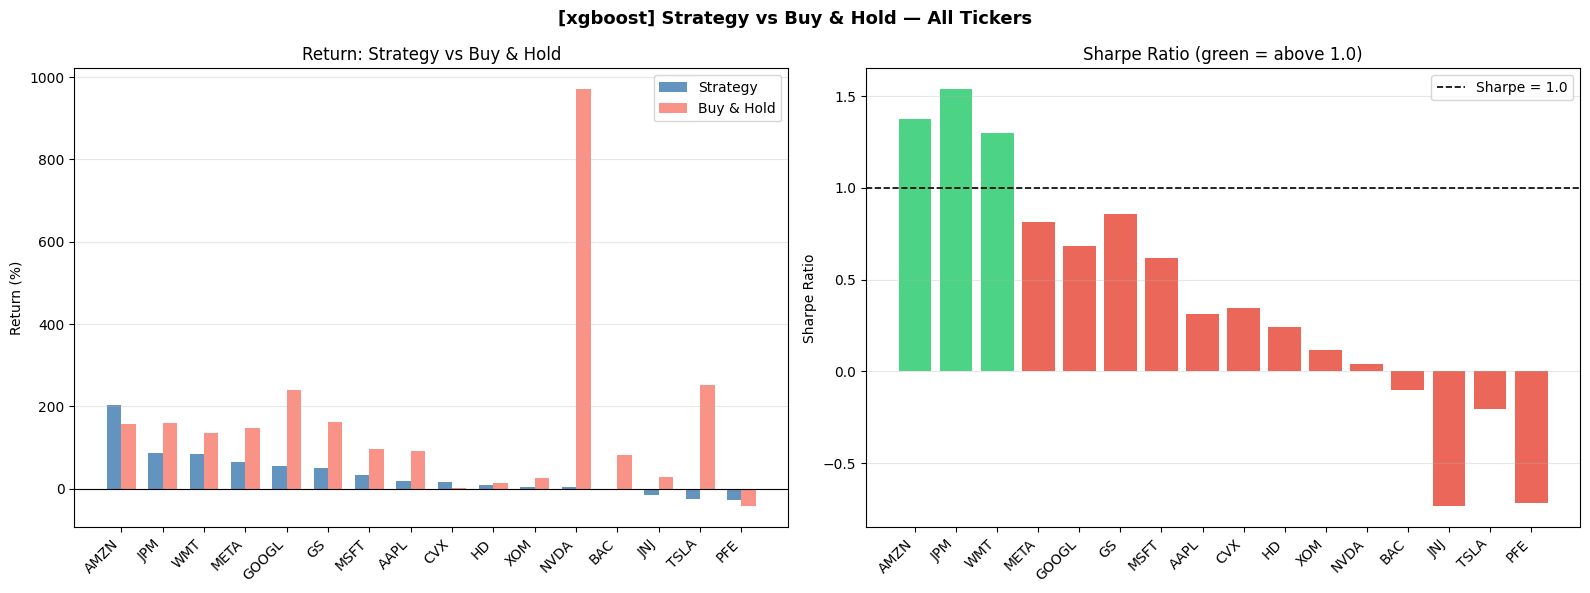

In [ ]:
summary_xgb = plot_backtest_summary(result_xgboost, model_name="xgboost")


  [tuned_xgboost] ALL-TICKER BACKTEST SUMMARY
         Return % Buy & Hold %    Sharpe   Max DD % Win Rate % # Trades Avg Trade % Profit Factor Beat B&H Sharpe OK
AMZN   464.690499    156.79734  1.645989 -12.426247      100.0       15   11.796158           NaN      Yes       Yes
NVDA   336.760474   970.588746  0.979182  -27.41336  70.731707       41    3.503844      3.831107       No        No
JPM    264.327904    159.46862  2.100655  -5.878599  83.333333       12   10.853123     52.555051      Yes       Yes
GS     222.165355   162.576763  1.560256 -11.899466  63.636364       11    9.796929      18.78932      Yes       Yes
BAC    150.827288     82.72389  1.653466  -8.184932  72.727273       11    7.583456     11.638152      Yes       Yes
TSLA   150.671096   252.873115  0.539867 -44.260117  46.666667       30    3.123369        2.0625       No        No
GOOGL  143.929416    238.89336   1.07132 -20.255344  55.882353       34     2.67748      2.898971       No       Yes
META   116.471314

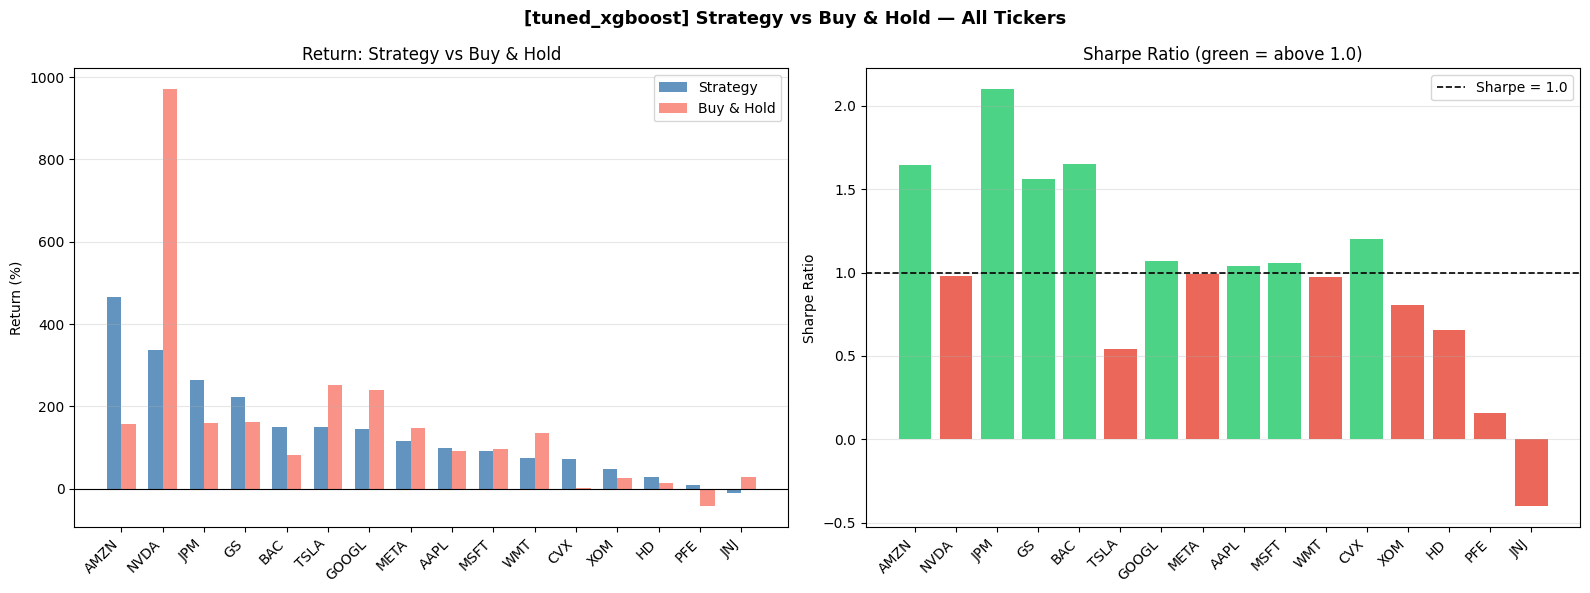

In [ ]:
summary_tuned_xgb = plot_backtest_summary(tuned_xgboost, model_name="tuned_xgboost")

#Saving the best model

In [ ]:
import joblib

SAVE_MODEL_NAME = OPTUNA_MODEL_NAME

joblib.dump(
    {
        'model': tuned_model,
        'scaler': tuned_scaler,
        'features': tuned_features
    },
    f'{SAVE_MODEL_NAME}.pkl'
)

print(f'Saved: {SAVE_MODEL_NAME}.pkl')

Saved: xgboost_tuned.pkl


#LSTM Model

In [ ]:
# LSTM config — adjust freely
LSTM_MODEL_NAME  = 'lstm_v1'   # used for saving files
LSTM_WINDOW      = 30          # how many past days to feed as a sequence
LSTM_HIDDEN      = 128         # number of hidden units per LSTM layer
LSTM_LAYERS      = 2           # number of stacked LSTM layers
LSTM_DROPOUT     = 0.3         # dropout between layers
LSTM_EPOCHS      = 50
LSTM_BATCH_SIZE  = 256
LSTM_LR          = 1e-3        # learning rate
LSTM_FRACTION    = TEST_FRACTION

In [ ]:
def make_sequences(X_arr, y_arr, window):

    Xs, ys = [], []
    for i in range(window, len(X_arr)):
        Xs.append(X_arr[i - window : i])   # past 'window' days
        ys.append(y_arr[i])                 # label for day i
    return np.array(Xs, dtype=np.float32), np.array(ys, dtype=np.int64)


class SequenceDataset(Dataset):
    def __init__(self, X_seq, y_seq):
        self.X = torch.tensor(X_seq)
        self.y = torch.tensor(y_seq)
    def __len__(self):
        return len(self.y)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


print('make_sequences and SequenceDataset defined')

make_sequences and SequenceDataset defined


In [ ]:
class LSTMClassifier(nn.Module):
    def __init__(self, input_size, hidden_size=128, num_layers=2,
                 dropout=0.3, num_classes=3):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size  = input_size,
            hidden_size = hidden_size,
            num_layers  = num_layers,
            dropout     = dropout if num_layers > 1 else 0.0,
            batch_first = True,     # input shape: (batch, seq_len, features)
        )
        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        # x shape: (batch, seq_len, input_size)
        out, _ = self.lstm(x)
        out     = self.dropout(out[:, -1, :])   # take last timestep only
        return self.fc(out)                      # (batch, 3)


print('LSTMClassifier defined')

LSTMClassifier defined


In [ ]:
def train_sequence_model(combined_df, model_class,
                          model_name='lstm_v1',
                          window=30, hidden=128, layers=2, dropout=0.3,
                          epochs=50, batch_size=256, lr=1e-3,
                          test_fraction=0.2):
    """
    General trainer for LSTM or GRU — pass model_class=LSTMClassifier or GRUClassifier.
    Returns: pytorch_model, scaler, feature_cols, train_history
    """
    available = [c for c in FEATURE_COLS if c in combined_df.columns]
    X_raw = combined_df[available].values.astype(np.float32)
    y_raw = combined_df['label'].values.astype(np.int64)

    # Train / test split
    split     = int(len(X_raw) * (1 - test_fraction))
    X_tr_raw  = X_raw[:split]
    X_te_raw  = X_raw[split:]
    y_tr_raw  = y_raw[:split]
    y_te_raw  = y_raw[split:]

    # Scale — fit on train only
    sc = StandardScaler()
    X_tr_scaled = sc.fit_transform(X_tr_raw)
    X_te_scaled = sc.transform(X_te_raw)

    # Build sequences
    X_tr_seq, y_tr_seq = make_sequences(X_tr_scaled, y_tr_raw, window)
    X_te_seq, y_te_seq = make_sequences(X_te_scaled, y_te_raw, window)

    train_ds = SequenceDataset(X_tr_seq, y_tr_seq)
    val_ds   = SequenceDataset(X_te_seq, y_te_seq)
    train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=False)
    val_dl   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False)

    # Class weights for imbalance
    counts   = np.bincount(y_tr_seq)
    weights  = torch.tensor(1.0 / counts, dtype=torch.float32).to(DEVICE)

    # Model
    net = model_class(
        input_size  = len(available),
        hidden_size = hidden,
        num_layers  = layers,
        dropout     = dropout,
    ).to(DEVICE)

    optimizer = torch.optim.Adam(net.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss(weight=weights)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, patience=5, factor=0.5)

    # Training loop
    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}
    best_val_loss = float('inf')
    best_state    = None

    print(f'[{model_name}] Training on {len(X_tr_seq):,} sequences  '
          f'| val on {len(X_te_seq):,}  |  window={window}  '
          f'epochs={epochs}  device={DEVICE}\n')

    for epoch in range(epochs):
        # Train
        net.train()
        tr_loss = 0
        for xb, yb in train_dl:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(net(xb), yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(net.parameters(), 1.0)
            optimizer.step()
            tr_loss += loss.item() * len(yb)
        tr_loss /= len(train_ds)

        # Validate
        net.eval()
        vl_loss, correct = 0, 0
        with torch.no_grad():
            for xb, yb in val_dl:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                logits = net(xb)
                vl_loss += criterion(logits, yb).item() * len(yb)
                correct += (logits.argmax(1) == yb).sum().item()
        vl_loss /= len(val_ds)
        vl_acc   = correct / len(val_ds)

        scheduler.step(vl_loss)
        history['train_loss'].append(tr_loss)
        history['val_loss'].append(vl_loss)
        history['val_acc'].append(vl_acc)

        # Save best weights
        if vl_loss < best_val_loss:
            best_val_loss = vl_loss
            best_state    = {k: v.cpu().clone() for k, v in net.state_dict().items()}

        if (epoch + 1) % 10 == 0:
            print(f'  Epoch {epoch+1:3d}/{epochs}  '
                  f'train_loss: {tr_loss:.4f}  '
                  f'val_loss: {vl_loss:.4f}  '
                  f'val_acc: {vl_acc:.3f}')

    # Load best weights
    net.load_state_dict(best_state)
    net.eval()
    print(f'\n [{model_name}] training complete  '
          f'(best val_loss: {best_val_loss:.4f})')

    # Plot training curves
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f'[{model_name}] Training Curves')
    axes[0].plot(history['train_loss'], label='Train Loss')
    axes[0].plot(history['val_loss'],   label='Val Loss')
    axes[0].set_title('Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    axes[1].plot(history['val_acc'], color='green', label='Val Accuracy')
    axes[1].set_title('Validation Accuracy')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return net, sc, available, history


print('train_sequence_model defined')

train_sequence_model defined


In [ ]:
class SequenceModelWrapper:
    def __init__(self, net, window, device=DEVICE):
        self.net    = net
        self.window = window
        self.device = device
        # These mirror sklearn attributes used by evaluate_model
        self.feature_importances_ = None

    def _to_sequences(self, X_arr):
        Xs = []
        for i in range(self.window, len(X_arr) + 1):
            Xs.append(X_arr[i - self.window : i])
        return np.array(Xs, dtype=np.float32)

    def predict_proba(self, X_arr):
        self.net.eval()
        seqs   = self._to_sequences(X_arr)
        tensor = torch.tensor(seqs).to(self.device)
        with torch.no_grad():
            logits = self.net(tensor)
            proba  = torch.softmax(logits, dim=1).cpu().numpy()
        # Pad front with zeros so length matches original X_arr
        pad   = np.zeros((self.window - 1, 3))
        return np.vstack([pad, proba])

    def predict(self, X_arr):
        return self.predict_proba(X_arr).argmax(axis=1)


print('SequenceModelWrapper defined')

SequenceModelWrapper defined


[lstm_v1] Training on 48,340 sequences  | val on 12,063  |  window=30  epochs=50  device=cpu

  Epoch  10/50  train_loss: 1.0705  val_loss: 1.1129  val_acc: 0.314
  Epoch  20/50  train_loss: 1.0054  val_loss: 1.2051  val_acc: 0.352
  Epoch  30/50  train_loss: 0.9692  val_loss: 1.2672  val_acc: 0.332
  Epoch  40/50  train_loss: 0.9542  val_loss: 1.2929  val_acc: 0.327
  Epoch  50/50  train_loss: 0.9496  val_loss: 1.2996  val_acc: 0.329

 [lstm_v1] training complete  (best val_loss: 1.0936)


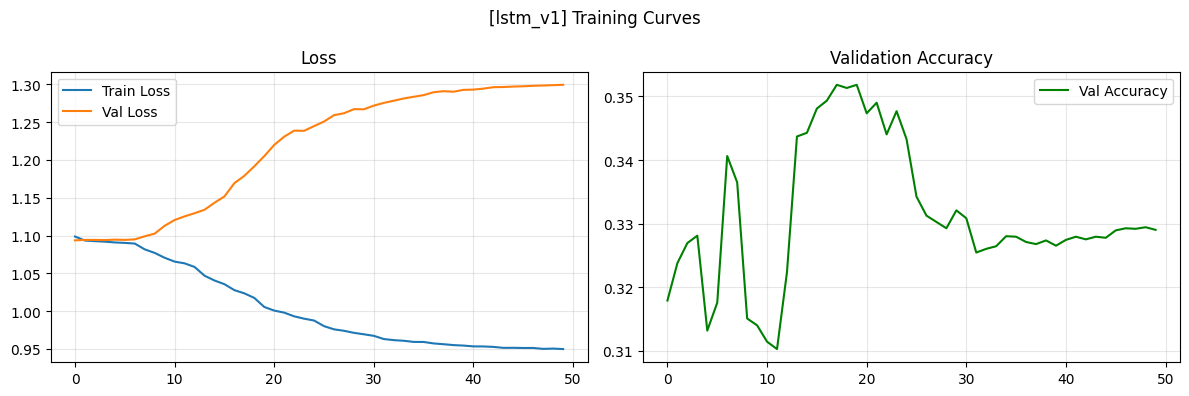

In [ ]:
# Train LSTM
lstm_net, lstm_scaler, lstm_features, lstm_history = train_sequence_model(
    combined,
    model_class = LSTMClassifier,
    model_name  = LSTM_MODEL_NAME,
    window      = LSTM_WINDOW,
    hidden      = LSTM_HIDDEN,
    layers      = LSTM_LAYERS,
    dropout     = LSTM_DROPOUT,
    epochs      = LSTM_EPOCHS,
    batch_size  = LSTM_BATCH_SIZE,
    lr          = LSTM_LR,
    test_fraction = LSTM_FRACTION,
)

# Wrap so it works with evaluate_model() and run_backtest()
lstm_model = SequenceModelWrapper(lstm_net, window=LSTM_WINDOW)


[lstm_v1] Holdout Evaluation (last 20% of combined data)

              precision    recall  f1-score   support

        SELL       0.08      0.00      0.01      2277
        HOLD       1.00      0.00      0.00      5905
         BUY       0.32      0.98      0.48      3911

    accuracy                           0.32     12093
   macro avg       0.47      0.33      0.16     12093
weighted avg       0.61      0.32      0.16     12093



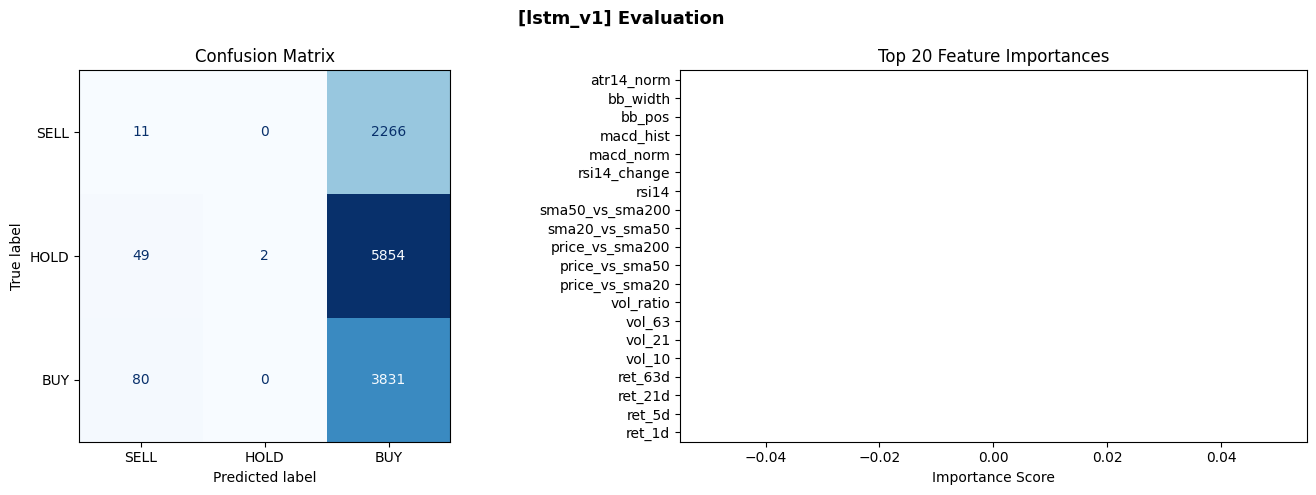

In [ ]:
# Evaluate — same function as XGBoost, just pass the wrapper
lstm_preds = evaluate_model(
    lstm_model, lstm_scaler, lstm_features, combined,
    model_name    = LSTM_MODEL_NAME,
    test_fraction = LSTM_FRACTION,
)

In [ ]:
all_stats = {}
total_invested = 0

for ticker in stock_data.keys():
    stats, bt = run_backtest(
        lstm_model, lstm_scaler, lstm_features, combined, stock_data,
        ticker=ticker
    )
    if stats is not None:
        all_stats[ticker] = stats
        total_invested += BT_CASH

# Summary
total_final   = sum(s['Equity Final [$]'] for s in all_stats.values())
total_profit  = total_final - total_invested
total_return  = (total_profit / total_invested) * 100 if total_invested > 0 else 0

# Build formatted summary
summary_text = (
    f"\n{'='*40}\n"
    f"  OVERALL PORTFOLIO SUMMARY\n"
    f"{'='*40}\n"
    f"  Tickers traded       {len(all_stats)}\n"
    f"  Total invested       ${total_invested:,.0f}\n"
    f"  Total final equity   ${total_final:,.2f}\n"
    f"  Total profit/loss    ${total_profit:,.2f}\n"
    f"  Overall return       {total_return:.2f}%\n"
)

result_lstm = {
    "tickers_traded": len(all_stats),
    "total_invested": total_invested,
    "total_final_equity": total_final,
    "total_profit_loss": total_profit,
    "overall_return_percent": total_return,
    "per_ticker_stats": all_stats,
    "summary": summary_text
}

print(result_lstm["summary"])

Backtest.run:   0%|          | 0/764 [00:00<?, ?bar/s]


  BACKTESTING — AAPL from 2022-12-12 to 2025-12-30
  Starting cash            $10,000
  Final equity             $19,204.41
  Strategy return          92.04%
  Buy & Hold return        91.85%
  Max drawdown             -33.16%
  Sharpe ratio             0.763
  Win rate                 nan%
  No. of Trades            0
  Avg trade return         nan%
  Profit factor            nan
  Calmar ratio             0.723

  Beat Buy&Hold: Yes
  Sharpe > 1.0:  No


Backtest.run:   0%|          | 0/764 [00:00<?, ?bar/s]


  BACKTESTING — MSFT from 2022-12-12 to 2025-12-30
  Starting cash            $10,000
  Final equity             $20,142.47
  Strategy return          101.42%
  Buy & Hold return        97.67%
  Max drawdown             -23.43%
  Sharpe ratio             0.919
  Win rate                 100.0%
  No. of Trades            1
  Avg trade return         58.92%
  Profit factor            nan
  Calmar ratio             1.107

  Beat Buy&Hold: Yes
  Sharpe > 1.0:  No


Backtest.run:   0%|          | 0/764 [00:00<?, ?bar/s]

...


  BACKTESTING — HD from 2022-12-12 to 2025-12-30
  Starting cash            $10,000
  Final equity             $11,837.19
  Strategy return          18.37%
  Buy & Hold return        13.97%
  Max drawdown             -21.58%
  Sharpe ratio             0.254
  Win rate                 nan%
  No. of Trades            0
  Avg trade return         nan%
  Profit factor            nan
  Calmar ratio             0.265

  Beat Buy&Hold: Yes
  Sharpe > 1.0:  No


Backtest.run:   0%|          | 0/740 [00:00<?, ?bar/s]


  BACKTESTING — TSLA from 2023-01-18 to 2025-12-30
  Starting cash            $10,000
  Final equity             $19,117.95
  Strategy return          91.18%
  Buy & Hold return        252.87%
  Max drawdown             -62.41%
  Sharpe ratio             0.326
  Win rate                 50.0%
  No. of Trades            2
  Avg trade return         4.20%
  Profit factor            2.43
  Calmar ratio             0.395

  Beat Buy&Hold: No
  Sharpe > 1.0:  No


Backtest.run:   0%|          | 0/764 [00:00<?, ?bar/s]


  BACKTESTING — NVDA from 2022-12-12 to 2025-12-30
  Starting cash            $10,000
  Final equity             $82,359.26
  Strategy return          723.59%
  Buy & Hold return        970.59%
  Max drawdown             -36.86%
  Sharpe ratio             0.983
  Win rate                 100.0%
  No. of Trades            4
  Avg trade return         52.19%
  Profit factor            nan
  Calmar ratio             2.721

  Beat Buy&Hold: No
  Sharpe > 1.0:  No

  OVERALL PORTFOLIO SUMMARY
  Tickers traded       16
  Total invested       $160,000
  Total final equity   $360,147.86
  Total profit/loss    $200,147.86
  Overall return       125.09%



## LSTM Backtest Summary


  [lstm] ALL-TICKER BACKTEST SUMMARY
         Return % Buy & Hold %    Sharpe   Max DD % Win Rate % # Trades Avg Trade % Profit Factor Beat B&H Sharpe OK
NVDA   723.592615   970.588746  0.983261 -36.862106      100.0        4   52.186555           NaN       No        No
GOOGL  186.744886    238.89336  0.980993 -30.165573      100.0        3   39.005152           NaN       No        No
GS     166.295933   162.576763  1.041559 -30.529391        NaN        0         NaN           NaN      Yes       Yes
JPM    148.429341    159.46862    1.1385 -24.305845      100.0        1   73.804908           NaN       No       Yes
WMT     142.16665   135.285236  1.285514 -21.887186        NaN        0         NaN           NaN      Yes       Yes
AMZN   140.834477    156.79734  0.793873 -29.439026      100.0        1   87.895935           NaN       No        No
META   116.598196   147.345035  0.739929 -31.731568      100.0        2   35.233438           NaN       No        No
MSFT   101.424725    97.66

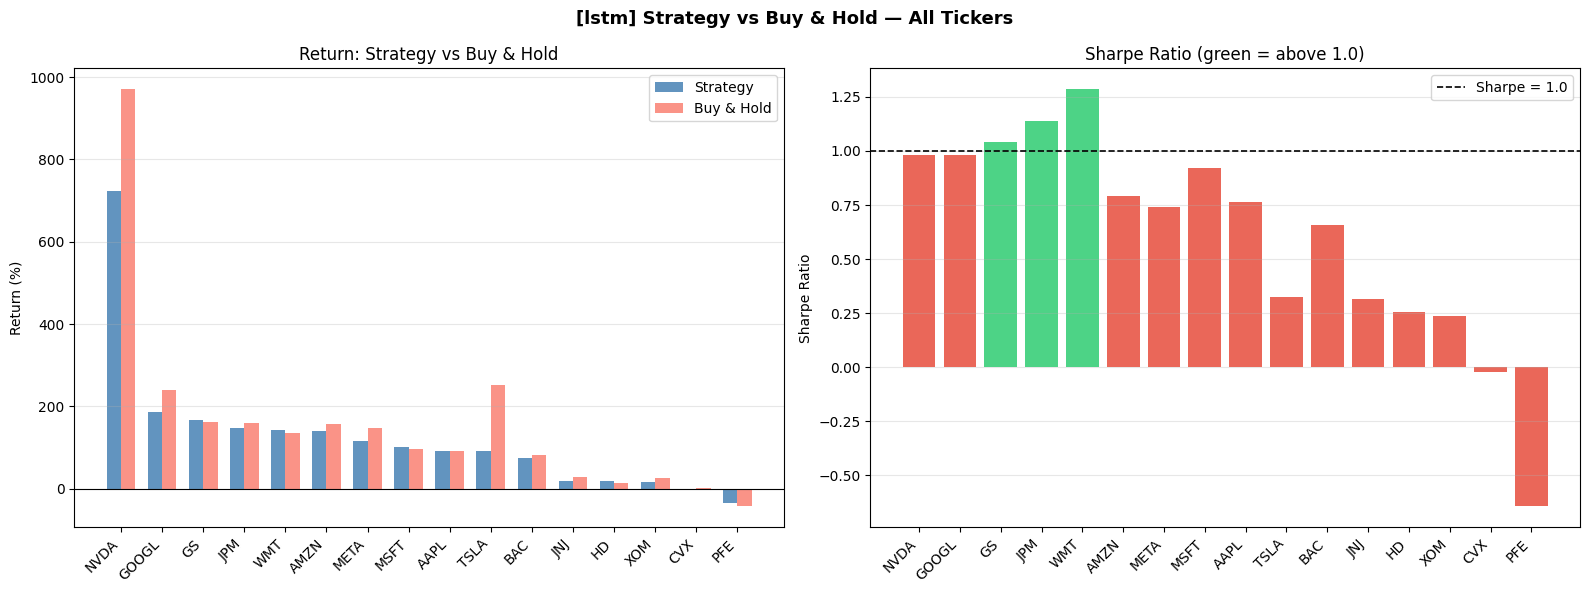

In [ ]:
summary_lstm = plot_backtest_summary(result_lstm, model_name="lstm")

#GRU model

In [ ]:
class GRUClassifier(nn.Module):
    def __init__(self, input_size, hidden_size=128, num_layers=2,
                 dropout=0.3, num_classes=3):
        super().__init__()
        self.gru = nn.GRU(
            input_size  = input_size,
            hidden_size = hidden_size,
            num_layers  = num_layers,
            dropout     = dropout if num_layers > 1 else 0.0,
            batch_first = True,
        )
        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        out, _ = self.gru(x)
        out     = self.dropout(out[:, -1, :])   # last timestep
        return self.fc(out)


print('GRUClassifier defined')

GRUClassifier defined


In [ ]:
GRU_MODEL_NAME  = 'gru_v1'
GRU_WINDOW      = 30
GRU_HIDDEN      = 128
GRU_LAYERS      = 2
GRU_DROPOUT     = 0.3
GRU_EPOCHS      = 50
GRU_BATCH_SIZE  = 256
GRU_LR          = 1e-3
GRU_FRACTION    = TEST_FRACTION

[gru_v1] Training on 48,340 sequences  | val on 12,063  |  window=30  epochs=50  device=cpu

  Epoch  10/50  train_loss: 1.0778  val_loss: 1.1511  val_acc: 0.243
  Epoch  20/50  train_loss: 1.0278  val_loss: 1.2088  val_acc: 0.308
  Epoch  30/50  train_loss: 0.9828  val_loss: 1.2939  val_acc: 0.306
  Epoch  40/50  train_loss: 0.9700  val_loss: 1.3131  val_acc: 0.305
  Epoch  50/50  train_loss: 0.9653  val_loss: 1.3201  val_acc: 0.304

 [gru_v1] training complete  (best val_loss: 1.0989)


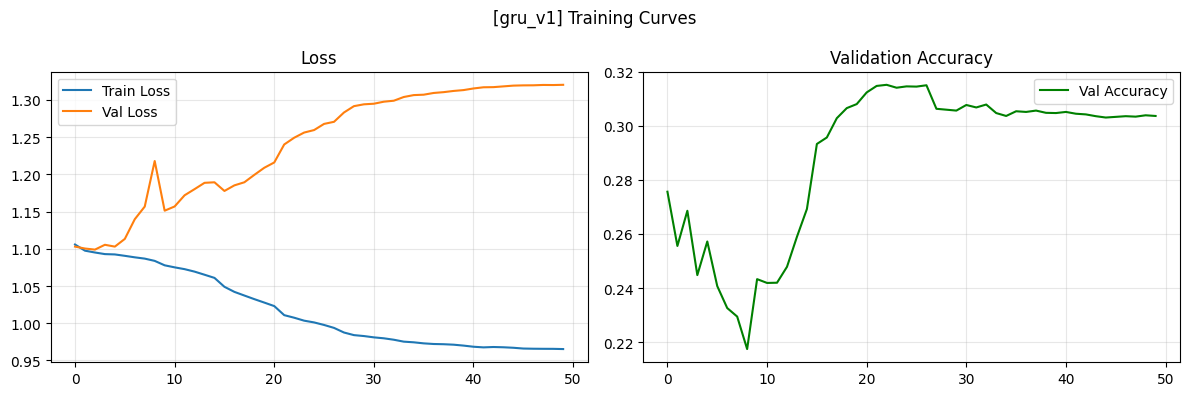

In [ ]:
gru_net, gru_scaler, gru_features, gru_history = train_sequence_model(
    combined,
    model_class = GRUClassifier,
    model_name  = GRU_MODEL_NAME,
    window      = GRU_WINDOW,
    hidden      = GRU_HIDDEN,
    layers      = GRU_LAYERS,
    dropout     = GRU_DROPOUT,
    epochs      = GRU_EPOCHS,
    batch_size  = GRU_BATCH_SIZE,
    lr          = GRU_LR,
    test_fraction = GRU_FRACTION,
)

gru_model = SequenceModelWrapper(gru_net, window=GRU_WINDOW)


[gru_v1] Holdout Evaluation (last 20% of combined data)

              precision    recall  f1-score   support

        SELL       0.20      0.53      0.29      2277
        HOLD       0.52      0.02      0.04      5905
         BUY       0.33      0.50      0.40      3911

    accuracy                           0.27     12093
   macro avg       0.35      0.35      0.24     12093
weighted avg       0.40      0.27      0.20     12093



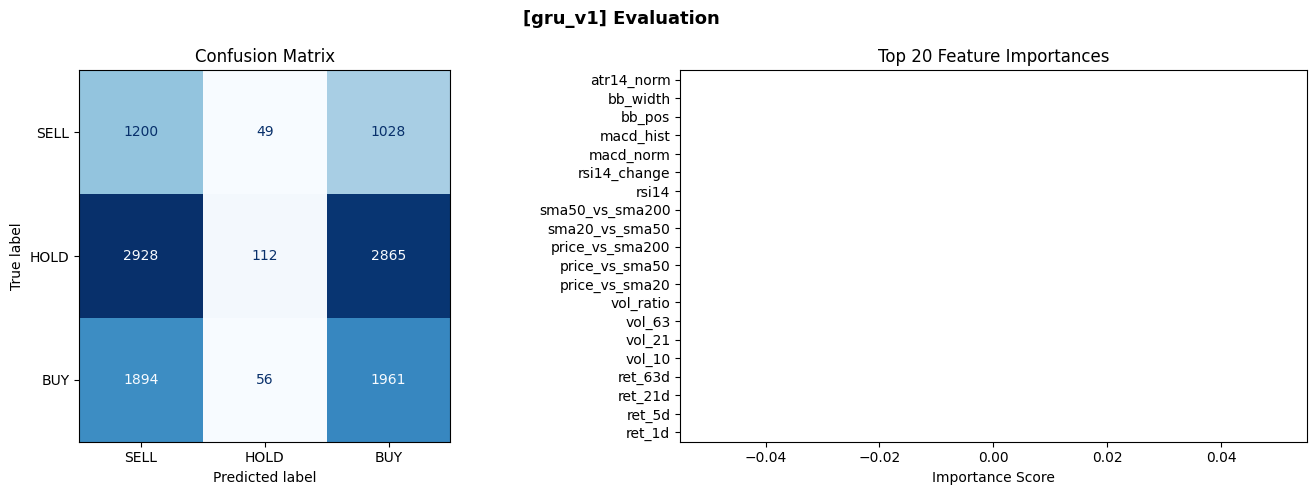

In [ ]:
gru_preds = evaluate_model(
    gru_model, gru_scaler, gru_features, combined,
    model_name    = GRU_MODEL_NAME,
    test_fraction = GRU_FRACTION,
)

In [ ]:
all_stats = {}
total_invested = 0

for ticker in stock_data.keys():
    stats, bt = run_backtest(
        gru_model, gru_scaler, gru_features, combined, stock_data,
        ticker=ticker
    )
    if stats is not None:
        all_stats[ticker] = stats
        total_invested += BT_CASH

# Summary
total_final   = sum(s['Equity Final [$]'] for s in all_stats.values())
total_profit  = total_final - total_invested
total_return  = (total_profit / total_invested) * 100 if total_invested > 0 else 0

# Build formatted summary
summary_text = (
    f"\n{'='*40}\n"
    f"  GRU OVERALL PORTFOLIO SUMMARY\n"
    f"{'='*40}\n"
    f"  Tickers traded       {len(all_stats)}\n"
    f"  Total invested       ${total_invested:,.0f}\n"
    f"  Total final equity   ${total_final:,.2f}\n"
    f"  Total profit/loss    ${total_profit:,.2f}\n"
    f"  Overall return       {total_return:.2f}%\n"
)

result_gru = {
    "tickers_traded": len(all_stats),
    "total_invested": total_invested,
    "total_final_equity": total_final,
    "total_profit_loss": total_profit,
    "overall_return_percent": total_return,
    "per_ticker_stats": all_stats,
    "summary": summary_text
}

print(result_gru["summary"])

Backtest.run:   0%|          | 0/764 [00:00<?, ?bar/s]


  BACKTESTING — AAPL from 2022-12-12 to 2025-12-30
  Starting cash            $10,000
  Final equity             $10,919.51
  Strategy return          9.20%
  Buy & Hold return        91.85%
  Max drawdown             -27.03%
  Sharpe ratio             0.165
  Win rate                 59.3%
  No. of Trades            27
  Avg trade return         0.29%
  Profit factor            1.20
  Calmar ratio             0.109

  Beat Buy&Hold: No
  Sharpe > 1.0:  No


Backtest.run:   0%|          | 0/764 [00:00<?, ?bar/s]


  BACKTESTING — MSFT from 2022-12-12 to 2025-12-30
  Starting cash            $10,000
  Final equity             $15,675.87
  Strategy return          56.76%
  Buy & Hold return        97.67%
  Max drawdown             -12.70%
  Sharpe ratio             0.825
  Win rate                 66.7%
  No. of Trades            24
  Avg trade return         1.86%
  Profit factor            2.64
  Calmar ratio             1.257

  Beat Buy&Hold: No
  Sharpe > 1.0:  No


Backtest.run:   0%|          | 0/764 [00:00<?, ?bar/s]

...


  BACKTESTING — HD from 2022-12-12 to 2025-12-30
  Starting cash            $10,000
  Final equity             $7,637.05
  Strategy return          -23.63%
  Buy & Hold return        13.97%
  Max drawdown             -32.17%
  Sharpe ratio             -0.632
  Win rate                 55.6%
  No. of Trades            27
  Avg trade return         -0.90%
  Profit factor            0.63
  Calmar ratio             -0.264

  Beat Buy&Hold: No
  Sharpe > 1.0:  No


Backtest.run:   0%|          | 0/740 [00:00<?, ?bar/s]


  BACKTESTING — TSLA from 2023-01-18 to 2025-12-30
  Starting cash            $10,000
  Final equity             $16,654.86
  Strategy return          66.55%
  Buy & Hold return        252.87%
  Max drawdown             -53.36%
  Sharpe ratio             0.335
  Win rate                 64.0%
  No. of Trades            25
  Avg trade return         1.96%
  Profit factor            1.73
  Calmar ratio             0.355

  Beat Buy&Hold: No
  Sharpe > 1.0:  No


Backtest.run:   0%|          | 0/764 [00:00<?, ?bar/s]


  BACKTESTING — NVDA from 2022-12-12 to 2025-12-30
  Starting cash            $10,000
  Final equity             $36,488.18
  Strategy return          264.88%
  Buy & Hold return        970.59%
  Max drawdown             -21.61%
  Sharpe ratio             1.001
  Win rate                 76.2%
  No. of Trades            21
  Avg trade return         6.39%
  Profit factor            13.10
  Calmar ratio             2.461

  Beat Buy&Hold: No
  Sharpe > 1.0:  Yes

  GRU OVERALL PORTFOLIO SUMMARY
  Tickers traded       16
  Total invested       $160,000
  Total final equity   $216,868.90
  Total profit/loss    $56,868.90
  Overall return       35.54%



## GRU Backtest Summary


  [gru] ALL-TICKER BACKTEST SUMMARY
         Return % Buy & Hold %    Sharpe   Max DD % Win Rate % # Trades Avg Trade % Profit Factor Beat B&H Sharpe OK
NVDA   264.881815   970.588746   1.00119 -21.607141  76.190476       21    6.388736     13.100257       No       Yes
TSLA    66.548594   252.873115  0.335184 -53.357797       64.0       25    1.963707      1.731313       No        No
META    65.585548   147.345035  0.739364 -18.845512  63.157895       19    2.660027      2.612431       No        No
MSFT    56.758688    97.669472  0.824884 -12.696952  66.666667       24    1.863371      2.638381       No        No
AMZN    47.883143    156.79734  0.506498  -28.00073  53.571429       28    1.160484       1.67624       No        No
WMT     46.837954   135.285236  0.820778 -13.179161  66.666667       21      1.8593      3.021427       No        No
GOOGL     39.0415    238.89336  0.476759 -29.777492       60.0       25    1.199209      1.660008       No        No
GS      37.971717   162.576

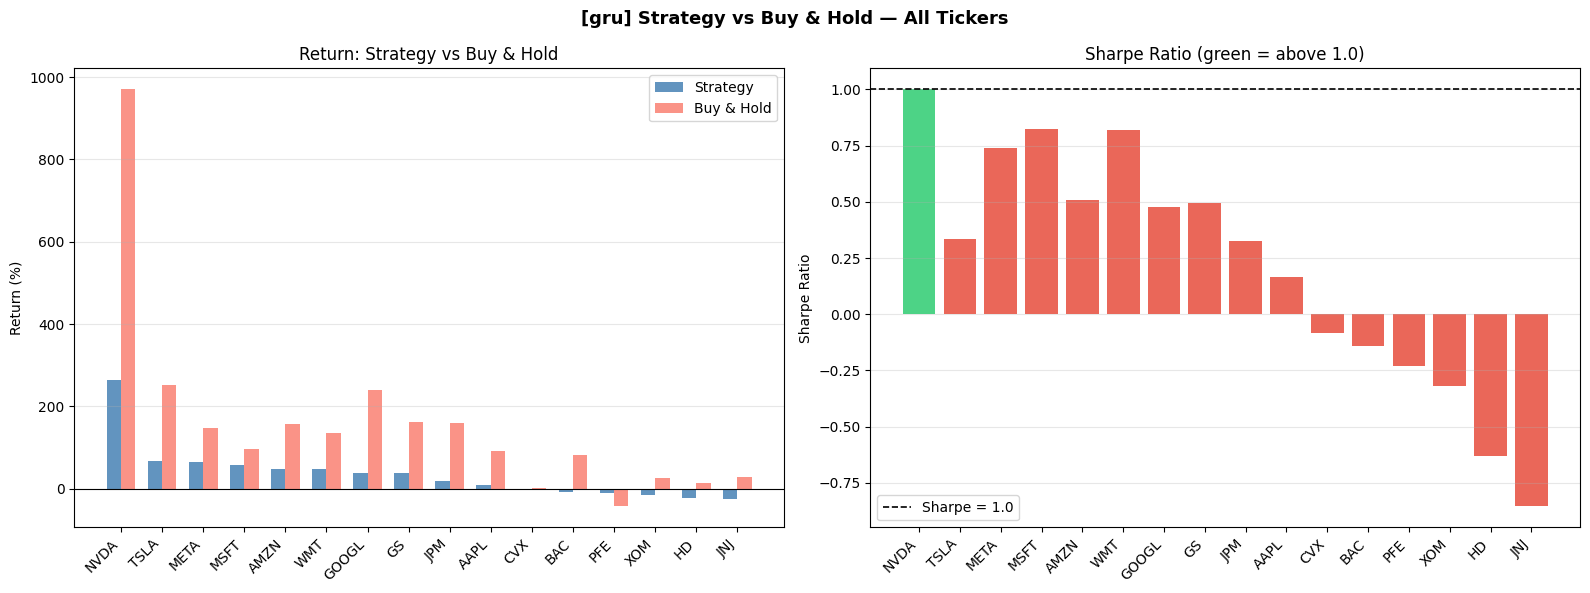

In [ ]:
summary_gru = plot_backtest_summary(result_gru, model_name="gru")

#Comparing all backtesting result

In [ ]:
print(result_xgboost["summary"])
print(tuned_xgboost["summary"])
print(result_lstm["summary"])
print(result_gru["summary"])


XGBoost  OVERALL PORTFOLIO SUMMARY
  Tickers traded       16
  Total invested       $160,000
  Total final equity   $216,047.47
  Total profit/loss    $56,047.47
  Overall return       35.03%


 XGBOOST TUNED OVERALL PORTFOLIO SUMMARY
  Tickers traded       16
  Total invested       $160,000
  Total final equity   $385,866.75
  Total profit/loss    $225,866.75
  Overall return       141.17%


  OVERALL PORTFOLIO SUMMARY
  Tickers traded       16
  Total invested       $160,000
  Total final equity   $360,147.86
  Total profit/loss    $200,147.86
  Overall return       125.09%


  GRU OVERALL PORTFOLIO SUMMARY
  Tickers traded       16
  Total invested       $160,000
  Total final equity   $216,868.90
  Total profit/loss    $56,868.90
  Overall return       35.54%

